In [1]:
from pathlib import Path
import gc
import json
import os
import warnings
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import polars as pl
from sklearn.metrics import average_precision_score
from scipy.stats import rankdata
from scipy.optimize import minimize, differential_evolution
from scipy.special import softmax
from catboost import CatBoostClassifier, Pool
import lightgbm as lgb
import xgboost as xgb
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import joblib
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.preprocessing import StandardScaler

pl.Config.set_tbl_rows(12)
pl.Config.set_tbl_cols(200)
warnings.filterwarnings("ignore")

DATA_DIR = Path("data/raw")
CACHE_DIR = Path("cache/meta3b1n")
SUBMISSION_DIR = Path("submission_meta")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

NEG_SAMPLE_MOD_RECENT = 10
NEG_SAMPLE_MOD_OLD = 30
NEG_SAMPLE_BORDER_STR = "2025-04-01 00:00:00"

VAL_START = pd.Timestamp("2025-05-01")
RECENCY_WEIGHT_START = pd.Timestamp("2025-02-01")

REFIT_ITER_MULT = 1.10
RANDOM_SEED = 67

FEATURE_CACHE_TAG = "v11_robust_features"
GLOBAL_CACHE_TAG = "v3_honest_eval"
FORCE_REBUILD_FEATURES = False
FORCE_REBUILD_PRIORS = False
USE_GPU = True

TRAIN_CB = False
TRAIN_LGB = False
TRAIN_XGB = False
TRAIN_ET = True
TRAIN_MLP = True

RETRAIN_ON_FULL_CB = True
RETRAIN_ON_FULL_LGB = True
RETRAIN_ON_FULL_XGB = True
RETRAIN_ON_FULL_ET = True
RETRAIN_ON_FULL_MLP = True

BLEND_METHOD = "nelder-mead"  # "nelder-mead", "grid-search", "diff-evolution"

try:
    import torch
    if torch.cuda.is_available():
        gpu = torch.cuda.get_device_properties(0)
        vram_gb = gpu.total_memory / 1024**3
        print(f"GPU: {gpu.name}, VRAM: {vram_gb:.1f} GB")
    else:
        print("CUDA not available, will use CPU")
        USE_GPU = False
except ImportError:
    print("torch not installed, GPU check skipped")

np.random.seed(RANDOM_SEED)

print("DATA_DIR:", DATA_DIR.resolve())
print("CACHE_DIR:", CACHE_DIR.resolve())



GPU: NVIDIA GeForce RTX 3060 Ti, VRAM: 8.0 GB
DATA_DIR: D:\prog\ml\data_fusion\local_df\data\raw
CACHE_DIR: D:\prog\ml\data_fusion\local_df\cache\meta3b1n


In [2]:
def make_weights(raw_target: np.ndarray, event_ts=None) -> np.ndarray:
    w = np.where(raw_target == 1, 10.0, np.where(raw_target == 0, 2.5, 1.0)).astype(np.float32)
    if event_ts is not None:
        ts = pd.to_datetime(event_ts)
        border = pd.Timestamp(NEG_SAMPLE_BORDER_STR)
        g = raw_target == -1
        w[g & (ts >= border)] = 1.8
        w[g & (ts < border)]  = 3.0
        w[ts >= RECENCY_WEIGHT_START] *= 1.15
    return w


def downcast_pandas(df, cat_cols_set=None):
    if cat_cols_set is None:
        cat_cols_set = set()
    for c in df.select_dtypes(include=['int64', 'int32']).columns:
        if c in cat_cols_set:
            continue
        col_min, col_max = df[c].min(), df[c].max()
        if pd.isna(col_min):
            continue
        if col_min >= -128 and col_max <= 127:
            df[c] = df[c].astype(np.int8)
        elif col_min >= -32768 and col_max <= 32767:
            df[c] = df[c].astype(np.int16)
        elif col_min >= -2147483648 and col_max <= 2147483647:
            df[c] = df[c].astype(np.int32)
    for c in df.select_dtypes(include=['float64']).columns:
        df[c] = df[c].astype(np.float32)
    return df


def rank_norm(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x)
    return rankdata(x, method="average") / (len(x) + 1.0)


def _fast_ap(y_true, y_score):
    desc = np.argsort(y_score)[::-1]
    y_sorted = y_true[desc]
    tp = np.cumsum(y_sorted)
    n_pos = tp[-1]
    if n_pos == 0:
        return 0.0
    prec = tp / np.arange(1, len(y_sorted) + 1)
    return float(np.sum(prec * y_sorted) / n_pos)


def optimize_blend_weights(heads: Dict[str, np.ndarray], y_true: np.ndarray, method: str = "nelder-mead"):
    keys = list(heads.keys())
    preds = [heads[k] for k in keys]
    y_np = np.asarray(y_true, dtype=np.int8)

    if method == "grid-search" and len(keys) <= 4:
        return _grid_search_blend(keys, preds, y_np)
    elif method == "diff-evolution":
        return _diff_evolution_blend(keys, preds, y_np)
    else:
        return _nelder_mead_blend(keys, preds, y_np)


def _nelder_mead_blend(keys, preds, y_true):
    def neg_ap(logits):
        w = softmax(logits)
        blend = sum(w[i] * preds[i] for i in range(len(keys)))
        return -average_precision_score(y_true, blend)
    x0 = np.zeros(len(keys), dtype=np.float64)
    res = minimize(neg_ap, x0, method="Nelder-Mead",
                   options={"maxiter": 1500, "xatol": 1e-4, "fatol": 1e-6})
    best_w = softmax(res.x).astype(np.float32)
    best_ap = float(-res.fun)
    return keys, best_w, best_ap


def _grid_search_blend(keys, preds, y_true, step=0.01):
    n = len(keys)
    if n == 2:
        best_ap, best_w = -1.0, np.array([0.5, 0.5], dtype=np.float32)
        for w0 in np.arange(0, 1 + step / 2, step):
            w1 = 1.0 - w0
            blend = w0 * preds[0] + w1 * preds[1]
            ap = _fast_ap(y_true, blend)
            if ap > best_ap:
                best_ap = ap
                best_w = np.array([w0, w1], dtype=np.float32)
        return keys, best_w, float(best_ap)
    elif n == 3:
        best_ap, best_w = -1.0, np.array([1/3]*3, dtype=np.float32)
        grid = np.arange(0, 1 + step / 2, step)
        for w0 in grid:
            for w1 in grid:
                w2 = 1.0 - w0 - w1
                if w2 < -1e-6:
                    break
                w2 = max(0.0, w2)
                blend = w0 * preds[0] + w1 * preds[1] + w2 * preds[2]
                ap = _fast_ap(y_true, blend)
                if ap > best_ap:
                    best_ap = ap
                    best_w = np.array([w0, w1, w2], dtype=np.float32)
        return keys, best_w, float(best_ap)
    elif n == 4:
        best_ap, best_w = -1.0, np.array([0.25]*4, dtype=np.float32)
        grid = np.arange(0, 1 + step / 2, step)
        for w0 in grid:
            for w1 in grid:
                if w0 + w1 > 1.0 + 1e-6:
                    break
                for w2 in grid:
                    w3 = 1.0 - w0 - w1 - w2
                    if w3 < -1e-6:
                        break
                    w3 = max(0.0, w3)
                    blend = w0 * preds[0] + w1 * preds[1] + w2 * preds[2] + w3 * preds[3]
                    ap = _fast_ap(y_true, blend)
                    if ap > best_ap:
                        best_ap = ap
                        best_w = np.array([w0, w1, w2, w3], dtype=np.float32)
        return keys, best_w, float(best_ap)
    else:
        return _nelder_mead_blend(keys, preds, y_true)


def _diff_evolution_blend(keys, preds, y_true):
    from scipy.optimize import differential_evolution
    n = len(keys)
    def neg_ap(weights):
        w = weights / weights.sum()
        blend = sum(w[i] * preds[i] for i in range(n))
        return -average_precision_score(y_true, blend)
    bounds = [(0.0, 1.0)] * n
    res = differential_evolution(neg_ap, bounds, maxiter=500, seed=RANDOM_SEED, tol=1e-6, polish=True)
    best_w = (res.x / res.x.sum()).astype(np.float32)
    best_ap = float(-res.fun)
    return keys, best_w, best_ap


def dedupe(items):
    seen = set()
    out = []
    for x in items:
        if x not in seen:
            seen.add(x)
            out.append(x)
    return out


def _lgb_prepare(X: pd.DataFrame, cat_cols: List[str]) -> pd.DataFrame:
    Xc = X.copy()
    for col in cat_cols:
        Xc[col] = Xc[col].fillna(-1).astype(np.int64) + 1
    return Xc


def _lgb_ap_metric(preds, dataset):
    y_true = dataset.get_label()
    return "ap", average_precision_score(y_true, preds), True


In [3]:
BASE_COLS = [
    "customer_id", "event_id", "event_dttm", "event_type_nm", "event_desc",
    "channel_indicator_type", "channel_indicator_sub_type", "operaton_amt", "currency_iso_cd",
    "mcc_code", "pos_cd",
    "accept_language", "browser_language",
    "timezone", "session_id", "operating_system_type",
    "battery", "device_system_version", "screen_size", "developer_tools",
    "phone_voip_call_state", "web_rdp_connection", "compromised",
]

FINAL_FEATURE_COLS = [
    # категориальные идентификаторы
    "customer_id", "event_type_nm", "event_desc", "channel_indicator_type",
    "channel_indicator_sub_type", "currency_iso_cd", "mcc_code_i", "pos_cd", "timezone",
    "operating_system_type", "phone_voip_call_state", "web_rdp_connection",
    "developer_tools_i", "compromised_i",
    "accept_language_i", "browser_language_i",
    "device_fp_i",

    # amount + missingness
    "amt", "amt_abs", "amt_log_abs", "amt_is_negative", "amt_bucket",
    "amt_missing", "currency_missing", "mcc_missing", "pos_missing",
    "accept_language_missing", "browser_language_missing", "timezone_missing",
    "session_id_missing", "operating_system_missing", "battery_missing",
    "device_system_version_missing", "screen_size_missing", "developer_tools_missing",
    "phone_voip_missing", "web_rdp_missing", "compromised_missing",

    # временные
    "hour", "weekday", "day", "is_weekend", "is_night",
    "hour_sin", "hour_cos", "weekday_sin", "weekday_cos", "month_sin", "month_cos",

    # устройство
    "battery_pct", "os_ver_major", "screen_w", "screen_h", "screen_pixels", "screen_ratio",

    # возраст аккаунта и активность
    "days_since_first_event", "cust_active_days", "avg_prev_events_per_active_day",

    # клиентская история объёмов
    "cust_prev_events", "cust_prev_amt_mean", "cust_prev_amt_std", "cust_prev_max_amt",
    "amt_vs_personal_max",
    "sec_since_prev_event", "days_since_prev_event",
    "amt_delta_prev", "amt_zscore",

    # сессионные
    "sec_since_session_start", "session_amt_before", "cnt_prev_same_session",

    # velocity-счётчики
    "cnt_prev_same_type", "cnt_prev_same_desc", "cnt_prev_same_mcc",
    "cnt_prev_same_subtype", "cnt_prev_same_channel_type",
    "cnt_prev_same_currency", "cnt_prev_same_device",
    "sec_since_prev_same_type", "sec_since_prev_same_desc",
    "sec_since_prev_same_channel_type", "sec_since_prev_same_currency", "sec_since_prev_same_device",
    "events_before_today", "cnt_events_this_hour",

    # флаги «впервые»
    "is_new_event_type", "is_new_event_desc", "is_new_channel_sub",
    "is_new_channel_type", "is_new_mcc", "is_new_currency",
    "is_new_device_fp", "is_first_in_session",

    # rolling
    "amt_sum_last_1h", "cnt_last_1h",
    "amt_sum_last_24h", "cnt_last_24h", "max_amt_last_24h",
    "amt_vs_1h_sum", "amt_vs_24h_sum",

    # история меток клиента
    "cust_prev_red_lbl_cnt", "cust_prev_yellow_lbl_cnt", "cust_prev_labeled_cnt",
    "cust_prev_red_lbl_rate", "cust_prev_yellow_lbl_rate", "cust_prev_susp_lbl_rate",
    "cust_prev_any_red_flag", "cust_prev_any_yellow_flag",
    "sec_since_prev_red_lbl", "sec_since_prev_yellow_lbl",

    # fine-grained label history
    "cnt_prev_labeled_same_desc", "cnt_prev_red_same_desc_lbl", "cnt_prev_yellow_same_desc_lbl",
    "red_rate_prev_same_desc_lbl",
    "cnt_prev_red_same_channel", "cnt_prev_labeled_same_channel", "red_rate_prev_same_channel",
    "cnt_prev_red_same_type_lbl", "cnt_prev_labeled_same_type_lbl", "red_rate_prev_same_type",
]

CAT_COLS = [
    "customer_id", "event_type_nm", "event_desc", "channel_indicator_type",
    "channel_indicator_sub_type", "currency_iso_cd", "mcc_code_i", "pos_cd",
    "timezone", "operating_system_type", "phone_voip_call_state", "web_rdp_connection",
    "developer_tools_i", "compromised_i",
    "accept_language_i", "browser_language_i",
    "device_fp_i",
]

META_COLS = [
    "event_id", "period", "event_ts",
    "is_train_sample", "is_test",
    "train_target_raw", "target_bin",
]

MODEL_DROP_COLS = {
    "target", "keep_green", "event_date", "event_hour_trunc",
    "month", "event_day_number",
    "session_id",
}

RISKY_LABEL_FEATURES = {
    "cnt_prev_labeled_same_desc", "cnt_prev_red_same_desc_lbl", "cnt_prev_yellow_same_desc_lbl",
    "red_rate_prev_same_desc_lbl",
    "cnt_prev_red_same_channel", "cnt_prev_labeled_same_channel", "red_rate_prev_same_channel",
    "cnt_prev_red_same_type_lbl", "cnt_prev_labeled_same_type_lbl", "red_rate_prev_same_type",
}

RISKY_PRIOR_SUFFIXES = (
    "_red_rate_all",
    "_labeled_rate_all",
    "_red_share_labeled",
)

labels_lf = pl.scan_parquet(DATA_DIR / "train_labels.parquet")
labels_df = pl.read_parquet(DATA_DIR / "train_labels.parquet")
print("Labels:", labels_df.shape)


Labels: (87514, 3)


In [4]:
FEATURE_CHUNK_SIZE = 3000  # customers per chunk


def _load_periods_for_chunk(part_id: int, cust_series: pl.Series) -> pl.LazyFrame:
    pretrain_lf = (
        pl.scan_parquet(DATA_DIR / f"pretrain_part_{part_id}.parquet")
        .filter(pl.col("customer_id").is_in(cust_series))
        .select(BASE_COLS)
        .with_columns(pl.lit("pretrain").alias("period"))
    )
    train_lf = (
        pl.scan_parquet(DATA_DIR / f"train_part_{part_id}.parquet")
        .filter(pl.col("customer_id").is_in(cust_series))
        .select(BASE_COLS)
        .with_columns(pl.lit("train").alias("period"))
    )
    pretest_lf = (
        pl.scan_parquet(DATA_DIR / "pretest.parquet")
        .filter(pl.col("customer_id").is_in(cust_series))
        .select(BASE_COLS)
        .unique()  # FIX: 130,360 duplicate rows in pretest
        .with_columns(pl.lit("pretest").alias("period"))
    )
    test_lf = (
        pl.scan_parquet(DATA_DIR / "test.parquet")
        .filter(pl.col("customer_id").is_in(cust_series))
        .select(BASE_COLS)
        .with_columns(pl.lit("test").alias("period"))
    )
    return pl.concat([pretrain_lf, train_lf, pretest_lf, test_lf], how="vertical_relaxed")


def _build_features_for_chunk(lf: pl.LazyFrame) -> pl.DataFrame:
    lf = (
        lf.with_columns([
            pl.col("event_dttm").str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S", strict=False).alias("event_ts"),
            pl.col("operaton_amt").cast(pl.Float64).alias("amt"),
            pl.col("session_id").cast(pl.Int64, strict=False).fill_null(-1).alias("session_id"),
            pl.col("event_type_nm").cast(pl.Int32, strict=False).fill_null(-1).alias("event_type_nm"),
            pl.col("event_desc").cast(pl.Int32, strict=False).fill_null(-1).alias("event_desc"),
            pl.col("channel_indicator_type").cast(pl.Int16, strict=False).fill_null(-1).alias("channel_indicator_type"),
            pl.col("channel_indicator_sub_type").cast(pl.Int16, strict=False).fill_null(-1).alias("channel_indicator_sub_type"),
            pl.col("currency_iso_cd").cast(pl.Int16, strict=False).fill_null(-1).alias("currency_iso_cd"),
            pl.col("pos_cd").cast(pl.Int16, strict=False).fill_null(-1).alias("pos_cd"),
            pl.col("timezone").cast(pl.Int32, strict=False).fill_null(-1).alias("timezone"),
            pl.col("operating_system_type").cast(pl.Int16, strict=False).fill_null(-1).alias("operating_system_type"),
            pl.col("phone_voip_call_state").cast(pl.Int8, strict=False).fill_null(-1).alias("phone_voip_call_state"),
            pl.col("web_rdp_connection").cast(pl.Int8, strict=False).fill_null(-1).alias("web_rdp_connection"),
            pl.col("mcc_code").cast(pl.Int32, strict=False).fill_null(-1).alias("mcc_code_i"),
            pl.col("battery").str.extract(r"(\d{1,3})", 1).cast(pl.Int16, strict=False).fill_null(-1).alias("battery_pct"),
            pl.col("device_system_version").str.extract(r"^(\d+)", 1).cast(pl.Int16, strict=False).fill_null(-1).alias("os_ver_major"),
            pl.col("screen_size").str.extract(r"^(\d+)", 1).cast(pl.Int16, strict=False).fill_null(-1).alias("screen_w"),
            pl.col("screen_size").str.extract(r"x(\d+)$", 1).cast(pl.Int16, strict=False).fill_null(-1).alias("screen_h"),
            pl.col("developer_tools").cast(pl.Int8, strict=False).fill_null(-1).alias("developer_tools_i"),
            pl.col("compromised").cast(pl.Int8, strict=False).fill_null(-1).alias("compromised_i"),
            pl.col("accept_language").cast(pl.Int32, strict=False).fill_null(-1).alias("accept_language_i"),
            pl.col("browser_language").cast(pl.Int32, strict=False).fill_null(-1).alias("browser_language_i"),

            pl.col("operaton_amt").is_null().cast(pl.Int8).alias("amt_missing"),
            pl.col("currency_iso_cd").is_null().cast(pl.Int8).alias("currency_missing"),
            pl.col("mcc_code").is_null().cast(pl.Int8).alias("mcc_missing"),
            pl.col("pos_cd").is_null().cast(pl.Int8).alias("pos_missing"),
            pl.col("accept_language").is_null().cast(pl.Int8).alias("accept_language_missing"),
            pl.col("browser_language").is_null().cast(pl.Int8).alias("browser_language_missing"),
            pl.col("timezone").is_null().cast(pl.Int8).alias("timezone_missing"),
            pl.col("session_id").is_null().cast(pl.Int8).alias("session_id_missing"),
            pl.col("operating_system_type").is_null().cast(pl.Int8).alias("operating_system_missing"),
            pl.col("battery").is_null().cast(pl.Int8).alias("battery_missing"),
            pl.col("device_system_version").is_null().cast(pl.Int8).alias("device_system_version_missing"),
            pl.col("screen_size").is_null().cast(pl.Int8).alias("screen_size_missing"),
            pl.col("developer_tools").is_null().cast(pl.Int8).alias("developer_tools_missing"),
            pl.col("phone_voip_call_state").is_null().cast(pl.Int8).alias("phone_voip_missing"),
            pl.col("web_rdp_connection").is_null().cast(pl.Int8).alias("web_rdp_missing"),
            pl.col("compromised").is_null().cast(pl.Int8).alias("compromised_missing"),
        ])
        .drop([
            "event_dttm", "operaton_amt", "mcc_code", "battery", "device_system_version",
            "screen_size", "developer_tools", "compromised", "accept_language", "browser_language",
        ])
        .sort(["customer_id", "event_ts", "event_id"])
    )

    lf = lf.with_columns([
        (
            pl.col("screen_w").cast(pl.Int64) * 100_000_000
            + pl.col("screen_h").cast(pl.Int64) * 100_000
            + pl.col("operating_system_type").cast(pl.Int64) * 1000
            + pl.col("accept_language_i").cast(pl.Int64) % 1000
        ).alias("device_fp_i"),
    ])

    lf = lf.join(labels_lf, on="event_id", how="left")
    lf = lf.with_columns([
        pl.when(pl.col("period") == "train")
          .then(pl.when(pl.col("target").is_null()).then(pl.lit(-1)).otherwise(pl.col("target")))
          .otherwise(pl.lit(None))
          .alias("train_target_raw")
    ])

    border_expr = pl.lit(NEG_SAMPLE_BORDER_STR).str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S", strict=False)
    lf = lf.with_columns([
        ((pl.col("period") == "train") &
         (pl.col("train_target_raw") == -1) &
         (((pl.col("event_ts") >= border_expr) & ((pl.struct(["event_id", "customer_id"]).hash(seed=RANDOM_SEED) % NEG_SAMPLE_MOD_RECENT) == 0)) |
          ((pl.col("event_ts") < border_expr)  & ((pl.struct(["event_id", "customer_id"]).hash(seed=RANDOM_SEED + 17) % NEG_SAMPLE_MOD_OLD) == 0))))
          .alias("keep_green")
    ])
    lf = lf.with_columns([
        ((pl.col("period") == "train") & ((pl.col("train_target_raw") != -1) | pl.col("keep_green"))).alias("is_train_sample"),
        (pl.col("period") == "test").alias("is_test"),
        pl.col("event_ts").dt.hour().cast(pl.Int8).alias("hour"),
        pl.col("event_ts").dt.weekday().cast(pl.Int8).alias("weekday"),
        pl.col("event_ts").dt.day().cast(pl.Int8).alias("day"),
        pl.col("event_ts").dt.month().cast(pl.Int8).alias("month"),
        (pl.col("event_ts").dt.weekday() >= 5).cast(pl.Int8).alias("is_weekend"),
        (pl.col("event_ts").dt.hour().is_in([0, 1, 2, 3, 4, 5])).cast(pl.Int8).alias("is_night"),
        (pl.col("event_ts").dt.epoch("s") // 86400).cast(pl.Int32).alias("event_day_number"),
        pl.col("event_ts").dt.date().alias("event_date"),
        pl.col("event_ts").dt.truncate("1h").alias("event_hour_trunc"),
        pl.col("amt").abs().cast(pl.Float32).alias("amt_abs"),
        pl.col("amt").abs().log1p().cast(pl.Float32).alias("amt_log_abs"),
        (pl.col("amt").abs().log1p() * 4.0).floor().clip(0, 63).cast(pl.Int16).alias("amt_bucket"),
        (pl.col("amt") < 0).cast(pl.Int8).alias("amt_is_negative"),
        (pl.col("screen_w").cast(pl.Int32) * pl.col("screen_h").cast(pl.Int32)).alias("screen_pixels"),
        pl.when((pl.col("screen_h") > 0) & (pl.col("screen_w") > 0))
          .then(pl.col("screen_w").cast(pl.Float32) / pl.col("screen_h").cast(pl.Float32))
          .otherwise(0.0).alias("screen_ratio"),
        (((pl.col("event_ts").dt.hour().cast(pl.Float32) / 24.0) * (2.0 * np.pi)).sin()).cast(pl.Float32).alias("hour_sin"),
        (((pl.col("event_ts").dt.hour().cast(pl.Float32) / 24.0) * (2.0 * np.pi)).cos()).cast(pl.Float32).alias("hour_cos"),
        (((pl.col("event_ts").dt.weekday().cast(pl.Float32) / 7.0) * (2.0 * np.pi)).sin()).cast(pl.Float32).alias("weekday_sin"),
        (((pl.col("event_ts").dt.weekday().cast(pl.Float32) / 7.0) * (2.0 * np.pi)).cos()).cast(pl.Float32).alias("weekday_cos"),
        (((pl.col("event_ts").dt.month().cast(pl.Float32) / 12.0) * (2.0 * np.pi)).sin()).cast(pl.Float32).alias("month_sin"),
        (((pl.col("event_ts").dt.month().cast(pl.Float32) / 12.0) * (2.0 * np.pi)).cos()).cast(pl.Float32).alias("month_cos"),
    ])

    lf = lf.with_columns([
        pl.col("event_ts").min().over("customer_id").alias("_cust_first_ts"),
    ])
    lf = lf.with_columns([
        ((pl.col("event_ts") - pl.col("_cust_first_ts")).dt.total_seconds() // 86400)
          .cast(pl.Int32).alias("days_since_first_event"),
    ])
    lf = lf.drop("_cust_first_ts")

    lf = lf.with_columns([
        pl.col("event_ts").min().over(["customer_id", "session_id"]).alias("_session_first_ts"),
        pl.col("amt").cum_sum().over(["customer_id", "session_id"]).alias("_session_cum_amt"),
    ])
    lf = lf.with_columns([
        ((pl.col("event_ts") - pl.col("_session_first_ts")).dt.total_seconds())
          .cast(pl.Int32).alias("sec_since_session_start"),
        (pl.col("_session_cum_amt") - pl.col("amt")).cast(pl.Float32).alias("session_amt_before"),
    ])
    lf = lf.drop(["_session_first_ts", "_session_cum_amt"])

    lf = lf.with_columns([
        ((pl.col("period") == "train") & (pl.col("train_target_raw") == 1)).cast(pl.Int8).alias("is_red_lbl"),
        ((pl.col("period") == "train") & (pl.col("train_target_raw") == 0)).cast(pl.Int8).alias("is_yellow_lbl"),
    ])
    lf = lf.with_columns([
        (pl.col("is_red_lbl") + pl.col("is_yellow_lbl")).cast(pl.Int8).alias("is_labeled_fb")
    ])

    lf = lf.with_columns([
        pl.cum_count("event_id").over("customer_id").cast(pl.Int32).alias("cust_event_idx"),
        pl.col("amt").cum_sum().over("customer_id").alias("cust_cum_amt"),
        (pl.col("amt") * pl.col("amt")).cum_sum().over("customer_id").alias("cust_cum_amt_sq"),
        pl.col("amt").cum_max().over("customer_id").alias("cust_cum_max_amt"),
        pl.col("event_ts").shift(1).over("customer_id").alias("prev_event_ts"),
        pl.col("event_date").shift(1).over("customer_id").alias("prev_event_date"),
        pl.col("amt").shift(1).over("customer_id").alias("prev_amt"),
        (pl.cum_count("event_id").over(["customer_id", "event_type_nm"]) - 1).cast(pl.Int16).alias("cnt_prev_same_type"),
        (pl.cum_count("event_id").over(["customer_id", "event_desc"]) - 1).cast(pl.Int16).alias("cnt_prev_same_desc"),
        (pl.cum_count("event_id").over(["customer_id", "mcc_code_i"]) - 1).cast(pl.Int16).alias("cnt_prev_same_mcc"),
        (pl.cum_count("event_id").over(["customer_id", "channel_indicator_sub_type"]) - 1).cast(pl.Int16).alias("cnt_prev_same_subtype"),
        (pl.cum_count("event_id").over(["customer_id", "channel_indicator_type"]) - 1).cast(pl.Int16).alias("cnt_prev_same_channel_type"),
        (pl.cum_count("event_id").over(["customer_id", "currency_iso_cd"]) - 1).cast(pl.Int16).alias("cnt_prev_same_currency"),
        (pl.cum_count("event_id").over(["customer_id", "device_fp_i"]) - 1).cast(pl.Int16).alias("cnt_prev_same_device"),
        (pl.cum_count("event_id").over(["customer_id", "session_id"]) - 1).cast(pl.Int16).alias("cnt_prev_same_session"),
        pl.col("event_ts").shift(1).over(["customer_id", "event_type_nm"]).alias("prev_same_type_ts"),
        pl.col("event_ts").shift(1).over(["customer_id", "event_desc"]).alias("prev_same_desc_ts"),
        pl.col("event_ts").shift(1).over(["customer_id", "channel_indicator_type"]).alias("prev_same_channel_type_ts"),
        pl.col("event_ts").shift(1).over(["customer_id", "currency_iso_cd"]).alias("prev_same_currency_ts"),
        pl.col("event_ts").shift(1).over(["customer_id", "device_fp_i"]).alias("prev_same_device_ts"),
        pl.col("is_red_lbl").cum_sum().over("customer_id").cast(pl.Int32).alias("cust_red_lbl_cum"),
        pl.col("is_yellow_lbl").cum_sum().over("customer_id").cast(pl.Int32).alias("cust_yellow_lbl_cum"),
        pl.col("is_labeled_fb").cum_sum().over("customer_id").cast(pl.Int32).alias("cust_labeled_fb_cum"),
        pl.col("is_red_lbl").cum_sum().over(["customer_id", "event_desc"]).cast(pl.Int16).alias("desc_red_lbl_cum"),
        pl.col("is_yellow_lbl").cum_sum().over(["customer_id", "event_desc"]).cast(pl.Int16).alias("desc_yellow_lbl_cum"),
        pl.col("is_labeled_fb").cum_sum().over(["customer_id", "event_desc"]).cast(pl.Int16).alias("desc_labeled_fb_cum"),
        pl.col("is_red_lbl").cum_sum().over(["customer_id", "channel_indicator_type"]).cast(pl.Int16).alias("chan_red_lbl_cum"),
        pl.col("is_labeled_fb").cum_sum().over(["customer_id", "channel_indicator_type"]).cast(pl.Int16).alias("chan_labeled_fb_cum"),
        pl.col("is_red_lbl").cum_sum().over(["customer_id", "event_type_nm"]).cast(pl.Int16).alias("type_red_lbl_cum"),
        pl.col("is_labeled_fb").cum_sum().over(["customer_id", "event_type_nm"]).cast(pl.Int16).alias("type_labeled_fb_cum"),
        pl.when(pl.col("is_red_lbl") == 1).then(pl.col("event_ts")).otherwise(None).alias("red_lbl_ts"),
        pl.when(pl.col("is_yellow_lbl") == 1).then(pl.col("event_ts")).otherwise(None).alias("yellow_lbl_ts"),
    ])

    lf = lf.with_columns([
        (pl.cum_count("event_id").over(["customer_id", "event_hour_trunc"]) - 1).cast(pl.Int16).alias("cnt_events_this_hour"),
    ])

    lf = lf.with_columns([
        pl.col("red_lbl_ts").shift(1).over("customer_id").alias("_red_shifted"),
        pl.col("yellow_lbl_ts").shift(1).over("customer_id").alias("_yellow_shifted"),
    ])
    lf = lf.with_columns([
        pl.col("_red_shifted").forward_fill().over("customer_id").alias("prev_red_lbl_ts"),
        pl.col("_yellow_shifted").forward_fill().over("customer_id").alias("prev_yellow_lbl_ts"),
    ])
    lf = lf.drop(["_red_shifted", "_yellow_shifted"])

    lf = lf.with_columns([
        (pl.col("cust_event_idx") - 1).cast(pl.Int32).alias("cust_prev_events"),
        pl.when(pl.col("cust_event_idx") > 1)
          .then((pl.col("cust_cum_amt") - pl.col("amt")) / (pl.col("cust_event_idx") - 1))
          .otherwise(0.0).cast(pl.Float32).alias("cust_prev_amt_mean"),
        pl.col("cust_cum_max_amt").shift(1).over("customer_id").fill_null(0.0).cast(pl.Float32).alias("cust_prev_max_amt"),
        pl.when(pl.col("prev_event_ts").is_not_null())
          .then((pl.col("event_ts") - pl.col("prev_event_ts")).dt.total_seconds())
          .otherwise(-1).cast(pl.Int32).alias("sec_since_prev_event"),
        (pl.col("amt") - pl.col("prev_amt").fill_null(0.0)).cast(pl.Float32).alias("amt_delta_prev"),
        pl.when(pl.col("prev_same_type_ts").is_not_null())
          .then((pl.col("event_ts") - pl.col("prev_same_type_ts")).dt.total_seconds())
          .otherwise(-1).cast(pl.Int32).alias("sec_since_prev_same_type"),
        pl.when(pl.col("prev_same_desc_ts").is_not_null())
          .then((pl.col("event_ts") - pl.col("prev_same_desc_ts")).dt.total_seconds())
          .otherwise(-1).cast(pl.Int32).alias("sec_since_prev_same_desc"),
        pl.when(pl.col("prev_same_channel_type_ts").is_not_null())
          .then((pl.col("event_ts") - pl.col("prev_same_channel_type_ts")).dt.total_seconds())
          .otherwise(-1).cast(pl.Int32).alias("sec_since_prev_same_channel_type"),
        pl.when(pl.col("prev_same_currency_ts").is_not_null())
          .then((pl.col("event_ts") - pl.col("prev_same_currency_ts")).dt.total_seconds())
          .otherwise(-1).cast(pl.Int32).alias("sec_since_prev_same_currency"),
        pl.when(pl.col("prev_same_device_ts").is_not_null())
          .then((pl.col("event_ts") - pl.col("prev_same_device_ts")).dt.total_seconds())
          .otherwise(-1).cast(pl.Int32).alias("sec_since_prev_same_device"),
        (pl.cum_count("event_id").over(["customer_id", "event_date"]) - 1).cast(pl.Int16).alias("events_before_today"),
        (pl.col("cust_red_lbl_cum") - pl.col("is_red_lbl")).cast(pl.Int32).alias("cust_prev_red_lbl_cnt"),
        (pl.col("cust_yellow_lbl_cum") - pl.col("is_yellow_lbl")).cast(pl.Int32).alias("cust_prev_yellow_lbl_cnt"),
        (pl.col("cust_labeled_fb_cum") - pl.col("is_labeled_fb")).cast(pl.Int32).alias("cust_prev_labeled_cnt"),
        (pl.col("desc_labeled_fb_cum") - pl.col("is_labeled_fb")).cast(pl.Int16).alias("cnt_prev_labeled_same_desc"),
        (pl.col("desc_red_lbl_cum") - pl.col("is_red_lbl")).cast(pl.Int16).alias("cnt_prev_red_same_desc_lbl"),
        (pl.col("desc_yellow_lbl_cum") - pl.col("is_yellow_lbl")).cast(pl.Int16).alias("cnt_prev_yellow_same_desc_lbl"),
        (pl.col("chan_red_lbl_cum") - pl.col("is_red_lbl")).cast(pl.Int16).alias("cnt_prev_red_same_channel"),
        (pl.col("chan_labeled_fb_cum") - pl.col("is_labeled_fb")).cast(pl.Int16).alias("cnt_prev_labeled_same_channel"),
        (pl.col("type_red_lbl_cum") - pl.col("is_red_lbl")).cast(pl.Int16).alias("cnt_prev_red_same_type_lbl"),
        (pl.col("type_labeled_fb_cum") - pl.col("is_labeled_fb")).cast(pl.Int16).alias("cnt_prev_labeled_same_type_lbl"),
        pl.when(pl.col("prev_red_lbl_ts").is_not_null())
          .then((pl.col("event_ts") - pl.col("prev_red_lbl_ts")).dt.total_seconds())
          .otherwise(-1).cast(pl.Int32).alias("sec_since_prev_red_lbl"),
        pl.when(pl.col("prev_yellow_lbl_ts").is_not_null())
          .then((pl.col("event_ts") - pl.col("prev_yellow_lbl_ts")).dt.total_seconds())
          .otherwise(-1).cast(pl.Int32).alias("sec_since_prev_yellow_lbl"),
    ])

    lf = lf.with_columns([
        pl.when(pl.col("cust_prev_events") > 0)
          .then((pl.col("prev_event_date").is_null() | (pl.col("event_date") != pl.col("prev_event_date"))).cast(pl.Int8))
          .otherwise(1).cast(pl.Int8).alias("_is_new_customer_day"),
        pl.when(pl.col("cust_event_idx") > 2)
          .then(
              ((pl.col("cust_cum_amt_sq") - pl.col("amt") * pl.col("amt")) / (pl.col("cust_event_idx") - 1)
               - pl.col("cust_prev_amt_mean") * pl.col("cust_prev_amt_mean"))
              .clip(lower_bound=0).sqrt())
          .otherwise(0.0).cast(pl.Float32).alias("cust_prev_amt_std"),
        ((pl.col("cust_prev_red_lbl_cnt") + 0.1) / (pl.col("cust_prev_labeled_cnt") + 1.0)).cast(pl.Float32).alias("cust_prev_red_lbl_rate"),
        ((pl.col("cust_prev_yellow_lbl_cnt") + 0.1) / (pl.col("cust_prev_labeled_cnt") + 1.0)).cast(pl.Float32).alias("cust_prev_yellow_lbl_rate"),
        (((pl.col("cust_prev_red_lbl_cnt") + pl.col("cust_prev_yellow_lbl_cnt")) + 0.1) / (pl.col("cust_prev_events") + 1.0)).cast(pl.Float32).alias("cust_prev_susp_lbl_rate"),
        (pl.col("cust_prev_red_lbl_cnt") > 0).cast(pl.Int8).alias("cust_prev_any_red_flag"),
        (pl.col("cust_prev_yellow_lbl_cnt") > 0).cast(pl.Int8).alias("cust_prev_any_yellow_flag"),
        ((pl.col("cnt_prev_red_same_desc_lbl") + 0.1) / (pl.col("cnt_prev_labeled_same_desc") + 1.0)).cast(pl.Float32).alias("red_rate_prev_same_desc_lbl"),
        ((pl.col("cnt_prev_red_same_channel") + 0.1) / (pl.col("cnt_prev_labeled_same_channel") + 1.0)).cast(pl.Float32).alias("red_rate_prev_same_channel"),
        ((pl.col("cnt_prev_red_same_type_lbl") + 0.1) / (pl.col("cnt_prev_labeled_same_type_lbl") + 1.0)).cast(pl.Float32).alias("red_rate_prev_same_type"),
    ])

    lf = lf.with_columns([
        (pl.col("_is_new_customer_day").cum_sum().over("customer_id") - 1).cast(pl.Int16).alias("cust_active_days"),
        pl.when(pl.col("cust_prev_amt_std") > 0)
          .then((pl.col("amt") - pl.col("cust_prev_amt_mean")) / (pl.col("cust_prev_amt_std") + 1.0))
          .otherwise(0.0).cast(pl.Float32).alias("amt_zscore"),
        pl.when(pl.col("cust_prev_max_amt").abs() > 1.0)
          .then(pl.col("amt") / (pl.col("cust_prev_max_amt").abs() + 1.0))
          .otherwise(0.0).cast(pl.Float32).alias("amt_vs_personal_max"),
        pl.when(pl.col("sec_since_prev_event") >= 0)
          .then(pl.col("sec_since_prev_event").cast(pl.Float32) / 86400.0)
          .otherwise(-1.0).cast(pl.Float32).alias("days_since_prev_event"),
        (pl.col("cnt_prev_same_type") == 0).cast(pl.Int8).alias("is_new_event_type"),
        (pl.col("cnt_prev_same_desc") == 0).cast(pl.Int8).alias("is_new_event_desc"),
        (pl.col("cnt_prev_same_subtype") == 0).cast(pl.Int8).alias("is_new_channel_sub"),
        (pl.col("cnt_prev_same_channel_type") == 0).cast(pl.Int8).alias("is_new_channel_type"),
        (pl.col("cnt_prev_same_mcc") == 0).cast(pl.Int8).alias("is_new_mcc"),
        (pl.col("cnt_prev_same_currency") == 0).cast(pl.Int8).alias("is_new_currency"),
        (pl.col("cnt_prev_same_device") == 0).cast(pl.Int8).alias("is_new_device_fp"),
        (pl.col("cnt_prev_same_session") == 0).cast(pl.Int8).alias("is_first_in_session"),
    ])

    lf = lf.with_columns([
        (pl.col("cust_prev_events") / (pl.col("cust_active_days") + 1.0)).cast(pl.Float32).alias("avg_prev_events_per_active_day"),
    ])

    lf = lf.with_columns([
        pl.when(pl.col("is_train_sample")).then((pl.col("train_target_raw") == 1).cast(pl.Int8)).otherwise(pl.lit(None)).alias("target_bin")
    ])

    _tmp = lf.select(["event_id", "customer_id", "event_ts", "amt"]).collect().to_pandas()
    _tmp["event_ts"] = pd.to_datetime(_tmp["event_ts"])
    _tmp = _tmp.sort_values(["customer_id", "event_ts", "event_id"]).reset_index(drop=True).set_index("event_ts")

    _results = []
    for _cust, _grp in _tmp.groupby("customer_id", sort=False):
        _s = _grp["amt"]
        _r = pd.DataFrame(index=_grp.index)
        _r["amt_sum_last_1h"]  = _s.rolling("1h",  closed="left").sum()
        _r["cnt_last_1h"]      = _s.rolling("1h",  closed="left").count()
        _r["amt_sum_last_24h"] = _s.rolling("24h", closed="left").sum()
        _r["cnt_last_24h"]     = _s.rolling("24h", closed="left").count()
        _r["max_amt_last_24h"] = _s.rolling("24h", closed="left").max()
        _r["event_id"] = _grp["event_id"].values
        _results.append(_r)

    _roll_df = pd.concat(_results).reset_index(drop=True).fillna(0)
    for c in ["amt_sum_last_1h", "amt_sum_last_24h", "max_amt_last_24h"]:
        _roll_df[c] = _roll_df[c].astype("float32")
    for c in ["cnt_last_1h", "cnt_last_24h"]:
        _roll_df[c] = _roll_df[c].astype("int16")
    _rolling_cols = ["amt_sum_last_1h", "cnt_last_1h", "amt_sum_last_24h", "cnt_last_24h", "max_amt_last_24h"]
    _rolling_lf = pl.from_pandas(_roll_df[["event_id"] + _rolling_cols].drop_duplicates(subset=["event_id"])).lazy()
    lf = lf.join(_rolling_lf, on="event_id", how="left")
    del _tmp, _roll_df, _results, _rolling_lf; gc.collect()

    lf = lf.with_columns([
        pl.when(pl.col("amt_sum_last_1h").abs() > 1.0)
          .then(pl.col("amt") / (pl.col("amt_sum_last_1h").abs() + 1.0))
          .otherwise(0.0).cast(pl.Float32).alias("amt_vs_1h_sum"),
        pl.when(pl.col("amt_sum_last_24h").abs() > 1.0)
          .then(pl.col("amt") / (pl.col("amt_sum_last_24h").abs() + 1.0))
          .otherwise(0.0).cast(pl.Float32).alias("amt_vs_24h_sum"),
    ])

    lf = lf.drop([
        "prev_event_date",
        "prev_same_type_ts", "prev_same_desc_ts",
        "prev_same_channel_type_ts", "prev_same_currency_ts", "prev_same_device_ts",
        "_is_new_customer_day",
    ])

    select_cols = META_COLS + FINAL_FEATURE_COLS
    seen = set()
    select_cols = [c for c in select_cols if not (c in seen or seen.add(c))]
    present = [c for c in select_cols if c in lf.columns]

    out_df = lf.filter(pl.col("is_train_sample") | pl.col("is_test")).select(present).collect()
    return out_df


def build_features_for_part(part_id: int, force: bool = False) -> Path:
    out_path = CACHE_DIR / f"features_{FEATURE_CACHE_TAG}_part_{part_id}.parquet"
    if out_path.exists() and not force:
        print(f"[part {part_id}] use cache -> {out_path.name}")
        return out_path

    print(f"[part {part_id}] building features (chunked, {FEATURE_CHUNK_SIZE} custs/chunk)...")
    custs = (
        pl.scan_parquet(DATA_DIR / f"pretrain_part_{part_id}.parquet")
        .select("customer_id").unique().collect()
        .get_column("customer_id").to_list()
    )
    print(f"  [part {part_id}] {len(custs):,} customers total")

    chunks = [custs[i:i+FEATURE_CHUNK_SIZE] for i in range(0, len(custs), FEATURE_CHUNK_SIZE)]
    results = []

    for ci, chunk_custs in enumerate(chunks):
        print(f"  [part {part_id}] chunk {ci+1}/{len(chunks)} ({len(chunk_custs)} custs) ...", end=" ", flush=True)
        cust_series = pl.Series("customer_id", chunk_custs)
        lf = _load_periods_for_chunk(part_id, cust_series)
        chunk_df = _build_features_for_chunk(lf)
        print(f"-> {chunk_df.height:,} rows")
        results.append(chunk_df)
        del chunk_df, lf
        gc.collect()

    out_df = pl.concat(results)
    out_df.write_parquet(out_path, compression="zstd")
    n_tr = out_df.filter(pl.col("is_train_sample")).height
    n_te = out_df.filter(pl.col("is_test")).height
    print(f"  [part {part_id}] saved: {out_df.shape} (train={n_tr:,}, test={n_te:,})")
    del out_df, results
    gc.collect()
    return out_path


In [5]:
def _device_fp_expr_from_raw() -> pl.Expr:
    return (
        (
            pl.col("screen_size").str.extract(r"^(\d+)", 1).cast(pl.Int16, strict=False).fill_null(-1).cast(pl.Int64) * 100_000_000
            + pl.col("screen_size").str.extract(r"x(\d+)$", 1).cast(pl.Int16, strict=False).fill_null(-1).cast(pl.Int64) * 100_000
            + pl.col("operating_system_type").cast(pl.Int16, strict=False).fill_null(-1).cast(pl.Int64) * 1000
            + (pl.col("accept_language").cast(pl.Int32, strict=False).fill_null(-1).cast(pl.Int64) % 1000)
        ).alias("device_fp_i")
    )


PRIOR_COL_DEFS = {
    "event_desc":                 pl.col("event_desc").cast(pl.Int32, strict=False).fill_null(-1).alias("event_desc"),
    "mcc_code_i":                 pl.col("mcc_code").cast(pl.Int32, strict=False).fill_null(-1).alias("mcc_code_i"),
    "timezone":                   pl.col("timezone").cast(pl.Int32, strict=False).fill_null(-1).alias("timezone"),
    "operating_system_type":      pl.col("operating_system_type").cast(pl.Int16, strict=False).fill_null(-1).alias("operating_system_type"),
    "channel_indicator_sub_type": pl.col("channel_indicator_sub_type").cast(pl.Int16, strict=False).fill_null(-1).alias("channel_indicator_sub_type"),
    "event_type_nm":              pl.col("event_type_nm").cast(pl.Int32, strict=False).fill_null(-1).alias("event_type_nm"),
    "pos_cd":                     pl.col("pos_cd").cast(pl.Int16, strict=False).fill_null(-1).alias("pos_cd"),
    "channel_indicator_type":     pl.col("channel_indicator_type").cast(pl.Int16, strict=False).fill_null(-1).alias("channel_indicator_type"),
    "accept_language_i":          pl.col("accept_language").cast(pl.Int32, strict=False).fill_null(-1).alias("accept_language_i"),
    "browser_language_i":         pl.col("browser_language").cast(pl.Int32, strict=False).fill_null(-1).alias("browser_language_i"),
    "device_fp_i":                _device_fp_expr_from_raw(),
}

DEVICE_STAT_COLS = [
    "device_n_distinct_customers",
    "device_n_distinct_sessions",
    "device_n_total_ops",
]


def _scan_train_prior_source(expr: pl.Expr, key_name: str, cutoff: pd.Timestamp | None = None) -> pl.LazyFrame:
    frames = []
    for i in [1, 2, 3]:
        lf = pl.scan_parquet(DATA_DIR / f"train_part_{i}.parquet").select([
            pl.col("event_id"),
            pl.col("event_dttm").str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S", strict=False).alias("event_ts"),
            expr,
        ])
        if cutoff is not None:
            lf = lf.filter(pl.col("event_ts") < pl.lit(cutoff.to_pydatetime()))
        frames.append(lf.select(["event_id", key_name]))
    return pl.concat(frames, how="vertical_relaxed")


def _make_prior_from_source(lf: pl.LazyFrame, key_name: str) -> pl.DataFrame:
    cnt_col = f"prior_{key_name}_cnt"
    lbl_cnt_col = f"prior_{key_name}_lbl_cnt"
    red_cnt_col = f"prior_{key_name}_red_cnt"

    total = lf.group_by(key_name).len().rename({"len": cnt_col})
    labeled = (
        lf.join(labels_lf, on="event_id", how="inner")
          .group_by(key_name)
          .agg([
              pl.len().alias(lbl_cnt_col),
              pl.sum("target").cast(pl.Float64).alias(red_cnt_col),
          ])
    )

    return (
        total.join(labeled, on=key_name, how="left")
             .with_columns([
                 pl.col(lbl_cnt_col).fill_null(0.0),
                 pl.col(red_cnt_col).fill_null(0.0),
             ])
             .with_columns([
                 ((pl.col(red_cnt_col) + 1.0) / (pl.col(cnt_col) + 200.0)).cast(pl.Float32).alias(f"prior_{key_name}_red_rate_all"),
                 ((pl.col(lbl_cnt_col) + 1.0) / (pl.col(cnt_col) + 200.0)).cast(pl.Float32).alias(f"prior_{key_name}_labeled_rate_all"),
                 ((pl.col(red_cnt_col) + 1.0) / (pl.col(lbl_cnt_col) + 2.0)).cast(pl.Float32).alias(f"prior_{key_name}_red_share_labeled"),
             ])
             .select([
                 key_name,
                 cnt_col,
                 f"prior_{key_name}_red_rate_all",
                 f"prior_{key_name}_labeled_rate_all",
                 f"prior_{key_name}_red_share_labeled",
             ])
             .collect()
    )


def build_prior_tables(tag: str, cutoff: pd.Timestamp | None = None, force: bool = False) -> Tuple[Dict[str, pd.DataFrame], List[str]]:
    tables: Dict[str, pd.DataFrame] = {}
    prior_feature_cols: List[str] = []

    for key_name, expr in PRIOR_COL_DEFS.items():
        out_path = CACHE_DIR / f"prior_{GLOBAL_CACHE_TAG}_{tag}_{key_name}.parquet"
        if out_path.exists() and not force:
            prior_df = pl.read_parquet(out_path)
        else:
            print(f"Building prior table: {tag} | {key_name}")
            source_lf = _scan_train_prior_source(expr, key_name, cutoff=cutoff)
            prior_df = _make_prior_from_source(source_lf, key_name)
            prior_df.write_parquet(out_path)

        tables[key_name] = prior_df.to_pandas()
        prior_feature_cols.extend([c for c in prior_df.columns if c != key_name])

    return tables, dedupe(prior_feature_cols)


def _scan_device_history(include_pretest: bool, cutoff: pd.Timestamp | None = None) -> pl.LazyFrame:
    base_cols = [
        "customer_id", "event_dttm", "session_id",
        "screen_size", "operating_system_type", "accept_language",
    ]
    frames = []
    for i in [1, 2, 3]:
        frames.append(pl.scan_parquet(DATA_DIR / f"pretrain_part_{i}.parquet").select(base_cols))
        frames.append(pl.scan_parquet(DATA_DIR / f"train_part_{i}.parquet").select(base_cols))

    if include_pretest:
        frames.append(pl.scan_parquet(DATA_DIR / "pretest.parquet").select(base_cols))

    lf = pl.concat(frames, how="diagonal_relaxed").with_columns([
        pl.col("event_dttm").str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S", strict=False).alias("event_ts"),
        pl.col("session_id").cast(pl.Int64, strict=False).fill_null(-1).alias("session_id"),
        _device_fp_expr_from_raw(),
    ])

    if cutoff is not None:
        lf = lf.filter(pl.col("event_ts") < pl.lit(cutoff.to_pydatetime()))

    return lf.select(["device_fp_i", "customer_id", "session_id"])


def build_device_stats_table(tag: str, cutoff: pd.Timestamp | None = None, include_pretest: bool = False, force: bool = False) -> pd.DataFrame:
    out_path = CACHE_DIR / f"device_stats_{GLOBAL_CACHE_TAG}_{tag}.parquet"
    if out_path.exists() and not force:
        return pl.read_parquet(out_path).to_pandas()

    print(f"Building device stats: {tag}")
    lf = _scan_device_history(include_pretest=include_pretest, cutoff=cutoff)
    stats_df = (
        lf.group_by("device_fp_i")
          .agg([
              pl.n_unique("customer_id").cast(pl.Int32).alias("device_n_distinct_customers"),
              pl.n_unique("session_id").cast(pl.Int32).alias("device_n_distinct_sessions"),
              pl.len().cast(pl.Int32).alias("device_n_total_ops"),
          ])
          .with_columns([
              pl.col("device_n_distinct_customers").log1p().cast(pl.Float32).alias("device_n_distinct_customers"),
              pl.col("device_n_distinct_sessions").log1p().cast(pl.Float32).alias("device_n_distinct_sessions"),
              pl.col("device_n_total_ops").log1p().cast(pl.Float32).alias("device_n_total_ops"),
          ])
          .collect()
    )
    stats_df.write_parquet(out_path)
    return stats_df.to_pandas()


def attach_global_features(base_df: pd.DataFrame, device_stats_df: pd.DataFrame, prior_tables: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    out = base_df.merge(device_stats_df, on="device_fp_i", how="left")
    for key_name, prior_df in prior_tables.items():
        out = out.merge(prior_df, on=key_name, how="left")
    return out


def audit_and_select_features(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    feature_cols: List[str],
    cat_cols: List[str],
) -> Tuple[List[str], pd.DataFrame]:
    rows = []
    keep_cols = []

    for col in feature_cols:
        if col not in train_df.columns or col not in test_df.columns:
            rows.append({
                "feature": col,
                "drop_reason": "missing_in_split",
                "train_nunique": np.nan,
                "test_nunique": np.nan,
                "train_missing_rate": np.nan,
                "test_missing_rate": np.nan,
                "dominant_share": np.nan,
            })
            continue

        s_tr = train_df[col]
        s_te = test_df[col]

        train_nunique = int(s_tr.nunique(dropna=False))
        test_nunique = int(s_te.nunique(dropna=False))
        train_missing_rate = float(s_tr.isna().mean())
        test_missing_rate = float(s_te.isna().mean())

        dominant_share = 0.0
        if (col in cat_cols) or (train_nunique <= 128) or (train_missing_rate >= 0.95):
            vc = s_tr.astype("object").value_counts(dropna=False, normalize=True)
            dominant_share = float(vc.iloc[0]) if len(vc) else 1.0

        drop_reason = "keep"
        if col in RISKY_LABEL_FEATURES:
            drop_reason = "risky_label_feature"
        elif any(col.endswith(sfx) for sfx in RISKY_PRIOR_SUFFIXES):
            drop_reason = "risky_label_prior"
        elif train_nunique <= 1:
            drop_reason = "constant"
        elif dominant_share >= 0.9995:
            drop_reason = "almost_constant"
        elif train_missing_rate >= 0.995 and test_missing_rate >= 0.995:
            drop_reason = "too_sparse"
        elif (col in cat_cols) and (train_missing_rate >= 0.85) and (train_nunique >= 20) and (test_nunique <= 2):
            drop_reason = "collapsed_in_test"

        rows.append({
            "feature": col,
            "drop_reason": drop_reason,
            "train_nunique": train_nunique,
            "test_nunique": test_nunique,
            "train_missing_rate": train_missing_rate,
            "test_missing_rate": test_missing_rate,
            "dominant_share": dominant_share,
        })

        if drop_reason == "keep":
            keep_cols.append(col)

    audit_df = pd.DataFrame(rows).sort_values(
        ["drop_reason", "train_missing_rate", "dominant_share", "feature"],
        ascending=[True, False, False, True],
    ).reset_index(drop=True)
    return keep_cols, audit_df


def prepare_feature_matrices(
    fit_df: pd.DataFrame,
    apply_dfs: List[pd.DataFrame],
    feature_cols: List[str],
    cat_cols: List[str],
) -> Tuple[pd.DataFrame, ...]:
    fit_X = fit_df[feature_cols].copy()
    apply_Xs = [df[feature_cols].copy() for df in apply_dfs]

    for c in cat_cols:
        fit_X[c] = fit_X[c].fillna(-1).astype(np.int64)
        for X in apply_Xs:
            X[c] = X[c].fillna(-1).astype(np.int64)

    num_cols = [c for c in feature_cols if c not in cat_cols]
    if num_cols:
        medians = fit_X[num_cols].median(numeric_only=True)
        fit_X[num_cols] = fit_X[num_cols].fillna(medians)
        for X in apply_Xs:
            X[num_cols] = X[num_cols].fillna(medians)

    return (fit_X, *apply_Xs)


In [6]:
feature_paths = []
for part_id in [1, 2, 3]:
    feature_paths.append(build_features_for_part(part_id, force=FORCE_REBUILD_FEATURES))

features = pl.concat([pl.scan_parquet(p) for p in feature_paths], how="vertical_relaxed").collect()
print("Feature table shape:", features.shape)

train_base_df = features.filter(pl.col("is_train_sample")).with_columns(
    pl.col("target_bin").cast(pl.Int8)
).to_pandas()
test_base_df = features.filter(pl.col("is_test")).to_pandas()
del features; gc.collect()

train_base_df["event_ts"] = pd.to_datetime(train_base_df["event_ts"])
test_base_df["event_ts"]  = pd.to_datetime(test_base_df["event_ts"])

train_base_df = train_base_df.sort_values(["event_ts", "event_id"]).reset_index(drop=True)
test_base_df  = test_base_df.sort_values(["event_ts", "event_id"]).reset_index(drop=True)

downcast_pandas(train_base_df)
downcast_pandas(test_base_df)

BASE_FEATURE_COLS = [c for c in train_base_df.columns if c not in META_COLS and c not in MODEL_DROP_COLS]
BASE_CAT_COLS = [c for c in CAT_COLS if c in BASE_FEATURE_COLS]
BASE_NUM_COLS = [c for c in BASE_FEATURE_COLS if c not in BASE_CAT_COLS]

print(f"Base features: {len(BASE_FEATURE_COLS)} | cat: {len(BASE_CAT_COLS)} | num: {len(BASE_NUM_COLS)}")
print(f"Train memory: {train_base_df.memory_usage(deep=True).sum() / 1e6:.0f} MB")


[part 1] use cache -> features_v11_robust_features_part_1.parquet
[part 2] use cache -> features_v11_robust_features_part_2.parquet
[part 3] use cache -> features_v11_robust_features_part_3.parquet
Feature table shape: (5222515, 126)
Base features: 119 | cat: 17 | num: 102
Train memory: 1501 MB


In [7]:
print("Building causal globals for local validation...")
device_stats_local = build_device_stats_table(tag="pre_val", cutoff=VAL_START, include_pretest=False, force=FORCE_REBUILD_PRIORS)
prior_tables_local, prior_feature_cols = build_prior_tables(tag="pre_val", cutoff=VAL_START, force=FORCE_REBUILD_PRIORS)

train_local_df = attach_global_features(train_base_df, device_stats_local, prior_tables_local)
test_local_df = attach_global_features(test_base_df, device_stats_local, prior_tables_local)
del device_stats_local, prior_tables_local; gc.collect()

raw_feature_cols = dedupe(BASE_FEATURE_COLS + DEVICE_STAT_COLS + prior_feature_cols)
raw_cat_feature_cols = [c for c in CAT_COLS if c in raw_feature_cols]

FEATURE_COLS, feature_audit_df = audit_and_select_features(train_local_df, test_local_df, raw_feature_cols, raw_cat_feature_cols)
CAT_FEATURE_COLS = [c for c in CAT_COLS if c in FEATURE_COLS]
NUM_FEATURE_COLS = [c for c in FEATURE_COLS if c not in CAT_FEATURE_COLS]

val_mask = train_local_df["event_ts"] >= VAL_START

print(f"Features after cleaning: {len(FEATURE_COLS)} | cat: {len(CAT_FEATURE_COLS)} | num: {len(NUM_FEATURE_COLS)}")
print("Dropped features by reason:")
print(feature_audit_df.loc[feature_audit_df["drop_reason"] != "keep", "drop_reason"].value_counts())



Building causal globals for local validation...
Features after cleaning: 118 | cat: 15 | num: 103
Dropped features by reason:
drop_reason
risky_label_prior      33
risky_label_feature    10
constant                4
almost_constant         1
Name: count, dtype: int64


In [8]:
main_train_df = train_local_df.loc[~val_mask].reset_index(drop=True)
main_val_df = train_local_df.loc[val_mask].reset_index(drop=True)
print(f"Main train: {len(main_train_df):,}  Main val: {len(main_val_df):,}")

X_main_tr, X_main_val, X_test = prepare_feature_matrices(
    main_train_df, [main_val_df, test_local_df], FEATURE_COLS, CAT_FEATURE_COLS
)

y_main_tr = main_train_df["target_bin"].astype(np.int8).values
y_main_val = main_val_df["target_bin"].astype(np.int8).values
w_main_tr = make_weights(main_train_df["train_target_raw"].values, main_train_df["event_ts"].values)
w_main_val = make_weights(main_val_df["train_target_raw"].values, main_val_df["event_ts"].values)

downcast_pandas(X_main_tr, set(CAT_FEATURE_COLS))
downcast_pandas(X_main_val, set(CAT_FEATURE_COLS))
downcast_pandas(X_test, set(CAT_FEATURE_COLS))

print(f"Features: {len(FEATURE_COLS)} | X_main_tr shape: {X_main_tr.shape}")
print(f"Test shape: {X_test.shape}")


Main train: 3,317,752  Main val: 1,271,080
Features: 118 | X_main_tr shape: (3317752, 118)
Test shape: (633683, 118)


In [9]:
# ==================== CATBOOST: TRAINING FUNCTIONS ====================

CB_PARAMS = {
    "iterations": 6000,
    "learning_rate": 0.04,
    "depth": 8,
    "l2_leaf_reg": 10.0,
    "random_strength": 0.5,
    "od_type": "Iter",
    "od_wait": 300,
}


def fit_catboost_with_holdout(X_tr, y_tr, w_tr, X_val, y_val, w_val, cat_cols, params, use_gpu=True):
    params = params.copy()
    params.update({
        "loss_function": "Logloss",
        "eval_metric": "PRAUC",
        "random_seed": RANDOM_SEED,
        "allow_writing_files": False,
        "verbose": 200,
        "metric_period": 100,
    })

    if use_gpu:
        params.update({"task_type": "GPU", "devices": "0"})
    else:
        params.update({"task_type": "CPU", "thread_count": max(1, (os.cpu_count() or 4) - 1)})

    tr_pool = Pool(X_tr, y_tr, weight=w_tr, cat_features=cat_cols)
    val_pool = Pool(X_val, y_val, weight=w_val, cat_features=cat_cols)

    def _fit_with_params(_params):
        model = CatBoostClassifier(**_params)
        model.fit(tr_pool, eval_set=val_pool, use_best_model=True)
        return model

    try:
        model = _fit_with_params(params)
    except Exception as e:
        print("CatBoost fallback:", e)
        params.pop("devices", None)
        params["task_type"] = "CPU"
        params["thread_count"] = max(1, (os.cpu_count() or 4) - 1)
        try:
            model = _fit_with_params(params)
        except Exception as e2:
            print("CatBoost PRAUC fallback -> AUC:", e2)
            params["eval_metric"] = "AUC"
            model = _fit_with_params(params)

    val_raw = model.predict(val_pool, prediction_type="RawFormulaVal")
    val_ap = average_precision_score(y_val, val_raw)

    best_iter = model.get_best_iteration()
    if best_iter is None:
        best_iter = int(params.get("iterations", 1000))
    else:
        best_iter = int(best_iter) + 1

    print(f"CB best_iter={best_iter}, val_pr_auc={val_ap:.6f}")
    return model, int(best_iter), float(val_ap), params


def refit_full_catboost(X, y, w, cat_cols, base_params, best_iter):
    params = {k: v for k, v in base_params.items() if k not in ("od_type", "od_wait")}
    params["iterations"] = int(max(100, round(best_iter * REFIT_ITER_MULT)))

    y_arr = np.asarray(y)
    w_arr = np.asarray(w, dtype=np.float32)
    if w_arr.ndim == 0 or w_arr.shape[0] != len(y_arr):
        w_arr = np.full(len(y_arr), float(np.nanmean(w_arr)) if w_arr.size > 0 else 1.0, dtype=np.float32)

    model = CatBoostClassifier(**params)
    model.fit(Pool(X, y_arr, weight=w_arr, cat_features=cat_cols), verbose=200)
    return model


In [10]:
# ==================== CATBOOST: TRAIN / VAL ====================

if TRAIN_CB:
    print("=" * 60)
    print("Training CatBoost MAIN model")
    print("=" * 60)
    model_cb, best_iter_cb, ap_cb, used_cb = fit_catboost_with_holdout(
        X_main_tr, y_main_tr, w_main_tr,
        X_main_val, y_main_val, w_main_val,
        cat_cols=CAT_FEATURE_COLS,
        params=CB_PARAMS,
        use_gpu=USE_GPU,
    )
    model_cb.save_model(str(CACHE_DIR / "cb_main.cbm"))

    val_pool = Pool(X_main_val, y_main_val, cat_features=CAT_FEATURE_COLS)
    pred_cb_val = model_cb.predict(val_pool, prediction_type="RawFormulaVal")
    del model_cb, val_pool; gc.collect()

    cb_meta = {
        "best_iter": best_iter_cb,
        "val_ap": ap_cb,
        "used_params": {k: str(v) for k, v in used_cb.items()},
    }
    with open(CACHE_DIR / "cb_meta.json", "w") as f:
        json.dump(cb_meta, f, indent=2)
    print(f"CatBoost val PR-AUC: {ap_cb:.6f}")

else:
    print("Loading CatBoost from cache...")
    with open(CACHE_DIR / "cb_meta.json") as f:
        cb_meta = json.load(f)
    best_iter_cb = cb_meta["best_iter"]
    ap_cb = cb_meta["val_ap"]

    model_cb = CatBoostClassifier().load_model(str(CACHE_DIR / "cb_main.cbm"))
    val_pool = Pool(X_main_val, y_main_val, cat_features=CAT_FEATURE_COLS)
    pred_cb_val = model_cb.predict(val_pool, prediction_type="RawFormulaVal")
    used_cb = cb_meta.get("used_params", CB_PARAMS)
    del model_cb, val_pool; gc.collect()
    print(f"CatBoost val PR-AUC: {ap_cb:.6f} (cached)")


Loading CatBoost from cache...
CatBoost val PR-AUC: 0.433256 (cached)


In [11]:
# ==================== LIGHTGBM: TRAINING FUNCTIONS ====================

LGB_PARAMS = {
    "n_estimators": 6000,
    "early_stopping_rounds": 300,
    "learning_rate": 0.03,
    "num_leaves": 255,
    "max_depth": -1,
    "min_child_samples": 80,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 0.75,
    "reg_alpha": 0.2,
    "reg_lambda": 8.0,
    "min_split_gain": 0.0,
    "max_bin": 255,
    "device": "cpu",
}


def fit_lgb_with_holdout(X_tr, y_tr, w_tr, X_val, y_val, w_val, cat_cols, params):
    p = params.copy()
    n_estimators = int(p.pop("n_estimators", 5000))
    early_stopping_rounds = int(p.pop("early_stopping_rounds", 200))
    p.update({
        "objective": "binary",
        "metric": "None",
        "seed": RANDOM_SEED,
        "verbosity": -1,
        "n_jobs": -1,
        "feature_pre_filter": False,
    })

    Xtr_ = _lgb_prepare(X_tr, cat_cols)
    Xval_ = _lgb_prepare(X_val, cat_cols)

    tr_ds = lgb.Dataset(Xtr_, label=y_tr, weight=w_tr, categorical_feature=cat_cols, free_raw_data=False)
    val_ds = lgb.Dataset(Xval_, label=y_val, weight=w_val, reference=tr_ds, categorical_feature=cat_cols, free_raw_data=False)

    callbacks = [
        lgb.early_stopping(early_stopping_rounds, first_metric_only=True, verbose=False),
        lgb.log_evaluation(200),
    ]

    model = lgb.train(
        p, tr_ds, num_boost_round=n_estimators,
        valid_sets=[val_ds], valid_names=["valid"],
        feval=_lgb_ap_metric, callbacks=callbacks,
    )

    best_iter = model.best_iteration or n_estimators
    val_raw = model.predict(Xval_, num_iteration=best_iter)
    val_ap = average_precision_score(y_val, val_raw)
    print(f"LGB best_iter={best_iter}, val_pr_auc={val_ap:.6f}")
    return model, int(best_iter), float(val_ap), p


def refit_full_lgb(X, y, w, cat_cols, base_params, best_iter):
    p = {k: v for k, v in base_params.items() if k not in ("n_estimators", "early_stopping_rounds")}
    p.update({
        "objective": "binary",
        "metric": "None",
        "seed": RANDOM_SEED,
        "verbosity": -1,
        "n_jobs": -1,
        "feature_pre_filter": False,
    })
    X_ = _lgb_prepare(X, cat_cols)
    ds = lgb.Dataset(X_, label=y, weight=w, categorical_feature=cat_cols, free_raw_data=False)
    model = lgb.train(p, ds, num_boost_round=int(max(100, round(best_iter * REFIT_ITER_MULT))))
    return model


In [12]:
# ==================== LIGHTGBM: TRAIN / VAL ====================

if TRAIN_LGB:
    print("=" * 60)
    print("Training LightGBM MAIN model")
    print("=" * 60)
    model_lgb, best_iter_lgb, ap_lgb, used_lgb = fit_lgb_with_holdout(
        X_main_tr, y_main_tr, w_main_tr,
        X_main_val, y_main_val, w_main_val,
        cat_cols=CAT_FEATURE_COLS,
        params=LGB_PARAMS,
    )
    model_lgb.save_model(str(CACHE_DIR / "lgb_main.txt"))

    pred_lgb_val = model_lgb.predict(
        _lgb_prepare(X_main_val, CAT_FEATURE_COLS),
        num_iteration=best_iter_lgb,
    )
    del model_lgb; gc.collect()

    lgb_meta = {"best_iter": best_iter_lgb, "val_ap": ap_lgb}
    with open(CACHE_DIR / "lgb_meta.json", "w") as f:
        json.dump(lgb_meta, f, indent=2)
    print(f"LightGBM val PR-AUC: {ap_lgb:.6f}")

else:
    print("Loading LightGBM from cache...")
    with open(CACHE_DIR / "lgb_meta.json") as f:
        lgb_meta = json.load(f)
    best_iter_lgb = lgb_meta["best_iter"]
    ap_lgb = lgb_meta["val_ap"]

    model_lgb = lgb.Booster(model_file=str(CACHE_DIR / "lgb_main.txt"))
    pred_lgb_val = model_lgb.predict(
        _lgb_prepare(X_main_val, CAT_FEATURE_COLS),
        num_iteration=best_iter_lgb,
    )
    used_lgb = LGB_PARAMS.copy()
    del model_lgb; gc.collect()
    print(f"LightGBM val PR-AUC: {ap_lgb:.6f} (cached)")


Loading LightGBM from cache...
LightGBM val PR-AUC: 0.479093 (cached)


In [13]:
# ==================== XGBOOST: TRAINING FUNCTIONS ====================

XGB_PARAMS = {
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "learning_rate": 0.04,
    "max_depth": 8,
    "min_child_weight": 1,
    "subsample": 1.0,
    "colsample_bytree": 1.0,
    "reg_alpha": 0.0,
    "reg_lambda": 10.0,
    "seed": RANDOM_SEED,
    "verbosity": 1,
    "tree_method": "hist",
    "device": "cuda",
    "max_bin": 255,
}


def fit_xgb_with_holdout(X_tr, y_tr, w_tr, X_val, y_val, w_val, params, n_estimators=6000):
    dtrain = xgb.DMatrix(X_tr, label=y_tr, weight=w_tr)
    dval = xgb.DMatrix(X_val, label=y_val, weight=w_val)

    try:
        model = xgb.train(
            params, dtrain, num_boost_round=n_estimators,
            evals=[(dval, "val")],
            early_stopping_rounds=300,
            verbose_eval=200,
        )
    except Exception as e:
        print(f"XGB GPU failed, fallback to CPU: {e}")
        params_cpu = params.copy()
        params_cpu["device"] = "cpu"
        params_cpu["tree_method"] = "hist"
        model = xgb.train(
            params_cpu, dtrain, num_boost_round=n_estimators,
            evals=[(dval, "val")],
            early_stopping_rounds=300,
            verbose_eval=200,
        )

    val_pred = model.predict(dval)
    val_ap = average_precision_score(y_val, val_pred)
    best_iter = model.best_iteration
    print(f"XGB best_iter={best_iter}, val_pr_auc={val_ap:.6f}")
    return model, best_iter, val_ap, val_pred


def refit_full_xgb(X, y, w, params, best_iter):
    n_iter = int(max(100, round(best_iter * REFIT_ITER_MULT)))
    dtrain = xgb.DMatrix(X, label=y, weight=w)
    model = xgb.train(params, dtrain, num_boost_round=n_iter, verbose_eval=200)
    return model


In [14]:
# ==================== XGBOOST: TRAIN / VAL ====================

if TRAIN_XGB:
    print("=" * 60)
    print("Training XGBoost MAIN model")
    print("=" * 60)
    model_xgb, best_iter_xgb, ap_xgb, pred_xgb_val = fit_xgb_with_holdout(
        X_main_tr, y_main_tr, w_main_tr,
        X_main_val, y_main_val, w_main_val,
        params=XGB_PARAMS,
    )
    model_xgb.save_model(str(CACHE_DIR / "xgb_main.json"))
    del model_xgb; gc.collect()

    xgb_meta = {"best_iter": best_iter_xgb, "val_ap": ap_xgb}
    with open(CACHE_DIR / "xgb_meta.json", "w") as f:
        json.dump(xgb_meta, f, indent=2)
    print(f"XGBoost val PR-AUC: {ap_xgb:.6f}")

else:
    print("Loading XGBoost from cache...")
    with open(CACHE_DIR / "xgb_meta.json") as f:
        xgb_meta = json.load(f)
    best_iter_xgb = xgb_meta["best_iter"]
    ap_xgb = xgb_meta["val_ap"]

    model_xgb = xgb.Booster()
    model_xgb.load_model(str(CACHE_DIR / "xgb_main.json"))
    dval = xgb.DMatrix(X_main_val)
    pred_xgb_val = model_xgb.predict(dval)
    del model_xgb, dval; gc.collect()
    print(f"XGBoost val PR-AUC: {ap_xgb:.6f} (cached)")


Loading XGBoost from cache...
XGBoost val PR-AUC: 0.466122 (cached)


In [16]:
# ==================== EXTRATREES: TRAINING & VALIDATION ====================

ET_PARAMS = {
    "n_estimators": 200,
    "max_depth": 16,
    "min_samples_leaf": 50,
    "max_features": "sqrt",
    "n_jobs": -1,
    "random_state": RANDOM_SEED,
    "class_weight": "balanced_subsample",
}

if TRAIN_ET:
    print("=" * 60)
    print("Training ExtraTrees...")
    print("=" * 60)

    model_et = ExtraTreesClassifier(**ET_PARAMS)
    model_et.fit(X_main_tr.values, y_main_tr, sample_weight=w_main_tr)

    pred_et_val = model_et.predict_proba(X_main_val.values)[:, 1]
    ap_et = average_precision_score(y_main_val, pred_et_val)
    best_iter_et = ET_PARAMS["n_estimators"]

    joblib.dump(model_et, CACHE_DIR / "et_main.joblib", compress=3)
    with open(CACHE_DIR / "et_meta.json", "w") as f:
        json.dump({"n_estimators": best_iter_et, "val_ap": float(ap_et)}, f, indent=2)

    del model_et; gc.collect()
    print(f"ExtraTrees val PR-AUC: {ap_et:.6f}")

else:
    print("Loading ExtraTrees from cache...")
    with open(CACHE_DIR / "et_meta.json") as f:
        et_meta = json.load(f)
    ap_et = et_meta["val_ap"]
    best_iter_et = et_meta["n_estimators"]

    model_et = joblib.load(CACHE_DIR / "et_main.joblib")
    pred_et_val = model_et.predict_proba(X_main_val.values)[:, 1]
    del model_et; gc.collect()
    print(f"ExtraTrees val PR-AUC: {ap_et:.6f} (cached)")


Training ExtraTrees...
ExtraTrees val PR-AUC: 0.335971


In [17]:
# ==================== SIMPLE MLP: TRAINING & VALIDATION ====================

MLP_HIDDEN_DIMS = [256, 128]
MLP_DROPOUT = 0.2
MLP_LR = 1e-3
MLP_WEIGHT_DECAY = 1e-4
MLP_BATCH_SIZE = 4096
MLP_MAX_EPOCHS = 20
MLP_PATIENCE = 5


class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropout=0.2):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.GELU(),
                nn.Dropout(dropout),
            ])
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def _train_mlp(
    X_tr_np, y_tr_np, w_tr_np, X_val_np, y_val_np,
    hidden_dims, dropout, lr, weight_decay, batch_size, max_epochs, patience, device,
):
    """Train a simple MLP with early stopping on val PR-AUC."""
    # Standardize features
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr_np).astype(np.float32)
    X_val_scaled = scaler.transform(X_val_np).astype(np.float32)

    # Replace NaN/Inf after scaling (edge case: constant features)
    X_tr_scaled = np.nan_to_num(X_tr_scaled, nan=0.0, posinf=0.0, neginf=0.0)
    X_val_scaled = np.nan_to_num(X_val_scaled, nan=0.0, posinf=0.0, neginf=0.0)

    # Tensors
    t_X_tr = torch.from_numpy(X_tr_scaled)
    t_y_tr = torch.from_numpy(y_tr_np.astype(np.float32))
    t_w_tr = torch.from_numpy(w_tr_np.astype(np.float32))
    t_X_val = torch.from_numpy(X_val_scaled)

    train_ds = TensorDataset(t_X_tr, t_y_tr, t_w_tr)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              pin_memory=(device.type == "cuda"), drop_last=False)

    # Model
    model = SimpleMLP(X_tr_scaled.shape[1], hidden_dims, dropout).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr, steps_per_epoch=len(train_loader), epochs=max_epochs,
    )
    grad_scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

    # Pos weight for class imbalance
    n_pos = float(y_tr_np.sum())
    n_neg = float(len(y_tr_np) - n_pos)
    pos_weight = torch.tensor([min(n_neg / max(n_pos, 1.0), 500.0)], device=device)

    best_ap = -1.0
    best_epoch = 0
    best_state = None
    wait = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        epoch_loss = 0.0
        n_batches = 0

        for batch_X, batch_y, batch_w in train_loader:
            batch_X = batch_X.to(device, non_blocking=True)
            batch_y = batch_y.to(device, non_blocking=True)
            batch_w = batch_w.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                logits = model(batch_X)
                loss_per_sample = F.binary_cross_entropy_with_logits(
                    logits, batch_y, pos_weight=pos_weight, reduction="none",
                )
                loss = (loss_per_sample * batch_w).mean()

            grad_scaler.scale(loss).backward()
            grad_scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            grad_scaler.step(optimizer)
            grad_scaler.update()
            scheduler.step()

            epoch_loss += loss.item()
            n_batches += 1

        # Validation
        model.eval()
        with torch.no_grad(), torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            val_logits = model(t_X_val.to(device))
            val_probs = torch.sigmoid(val_logits).cpu().numpy()

        val_ap = average_precision_score(y_val_np, val_probs)
        avg_loss = epoch_loss / max(n_batches, 1)
        print(f"  Epoch {epoch}/{max_epochs} | loss={avg_loss:.4f} | val PR-AUC={val_ap:.6f}")

        if val_ap > best_ap:
            best_ap = val_ap
            best_epoch = epoch
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stopping at epoch {epoch} (patience={patience})")
                break

        gc.collect()
        if device.type == "cuda":
            torch.cuda.empty_cache()

    # Load best state and get final predictions
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad(), torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
        val_logits = model(t_X_val.to(device))
        val_preds = torch.sigmoid(val_logits).cpu().numpy()

    del model, optimizer, grad_scaler, scheduler
    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()

    return val_preds, best_ap, best_epoch, best_state, scaler


if TRAIN_MLP:
    print("=" * 60)
    print("Training Simple MLP...")
    print("=" * 60)

    mlp_device = torch.device("cuda" if torch.cuda.is_available() and USE_GPU else "cpu")
    print(f"MLP device: {mlp_device}")

    pred_mlp_val, ap_mlp, best_epoch_mlp, mlp_best_state, mlp_scaler = _train_mlp(
        X_main_tr.values, y_main_tr, w_main_tr,
        X_main_val.values, y_main_val,
        MLP_HIDDEN_DIMS, MLP_DROPOUT, MLP_LR, MLP_WEIGHT_DECAY,
        MLP_BATCH_SIZE, MLP_MAX_EPOCHS, MLP_PATIENCE, mlp_device,
    )

    # Save checkpoint
    torch.save({
        "state_dict": mlp_best_state,
        "input_dim": X_main_tr.shape[1],
        "hidden_dims": MLP_HIDDEN_DIMS,
        "dropout": MLP_DROPOUT,
        "best_epoch": best_epoch_mlp,
        "best_ap": ap_mlp,
    }, CACHE_DIR / "mlp_val.pt")
    joblib.dump(mlp_scaler, CACHE_DIR / "mlp_scaler.joblib")

    with open(CACHE_DIR / "mlp_meta.json", "w") as f:
        json.dump({"best_epoch": best_epoch_mlp, "val_ap": float(ap_mlp)}, f, indent=2)

    del mlp_best_state; gc.collect()
    print(f"MLP best epoch: {best_epoch_mlp}, val PR-AUC: {ap_mlp:.6f}")

else:
    print("Loading MLP from cache...")
    with open(CACHE_DIR / "mlp_meta.json") as f:
        mlp_meta = json.load(f)
    best_epoch_mlp = mlp_meta["best_epoch"]
    ap_mlp = mlp_meta["val_ap"]

    mlp_device = torch.device("cuda" if torch.cuda.is_available() and USE_GPU else "cpu")
    mlp_scaler = joblib.load(CACHE_DIR / "mlp_scaler.joblib")
    ckpt = torch.load(CACHE_DIR / "mlp_val.pt", map_location=mlp_device, weights_only=True)
    mlp_model_cached = SimpleMLP(ckpt["input_dim"], ckpt["hidden_dims"], ckpt["dropout"]).to(mlp_device)
    mlp_model_cached.load_state_dict(ckpt["state_dict"])
    mlp_model_cached.eval()

    X_val_scaled = mlp_scaler.transform(X_main_val.values).astype(np.float32)
    X_val_scaled = np.nan_to_num(X_val_scaled, nan=0.0, posinf=0.0, neginf=0.0)
    with torch.no_grad(), torch.amp.autocast("cuda", enabled=(mlp_device.type == "cuda")):
        pred_mlp_val = torch.sigmoid(
            mlp_model_cached(torch.from_numpy(X_val_scaled).to(mlp_device))
        ).cpu().numpy()

    del mlp_model_cached, ckpt; gc.collect()
    print(f"MLP val PR-AUC: {ap_mlp:.6f} (cached)")


Training Simple MLP...
MLP device: cuda
  Epoch 1/20 | loss=4.6680 | val PR-AUC=0.260840
  Epoch 2/20 | loss=3.7953 | val PR-AUC=0.325925
  Epoch 3/20 | loss=3.6376 | val PR-AUC=0.349068
  Epoch 4/20 | loss=3.5461 | val PR-AUC=0.357080
  Epoch 5/20 | loss=3.5090 | val PR-AUC=0.371297
  Epoch 6/20 | loss=3.4665 | val PR-AUC=0.373813
  Epoch 7/20 | loss=3.4310 | val PR-AUC=0.369862
  Epoch 8/20 | loss=3.4093 | val PR-AUC=0.386814
  Epoch 9/20 | loss=3.3590 | val PR-AUC=0.389300
  Epoch 10/20 | loss=3.3586 | val PR-AUC=0.378086
  Epoch 11/20 | loss=3.3023 | val PR-AUC=0.390701
  Epoch 12/20 | loss=3.2849 | val PR-AUC=0.392268
  Epoch 13/20 | loss=3.2559 | val PR-AUC=0.394920
  Epoch 14/20 | loss=3.2446 | val PR-AUC=0.388995
  Epoch 15/20 | loss=3.2132 | val PR-AUC=0.390728
  Epoch 16/20 | loss=3.1916 | val PR-AUC=0.394793
  Epoch 17/20 | loss=3.1787 | val PR-AUC=0.397251
  Epoch 18/20 | loss=3.1542 | val PR-AUC=0.399879
  Epoch 19/20 | loss=3.1359 | val PR-AUC=0.396542
  Epoch 20/20 | los

In [18]:
# ==================== BLEND COMBINATIONS ====================

# -- All val predictions in rank-normalized space --
all_val_heads = {
    "catboost": rank_norm(pred_cb_val),
    "lightgbm": rank_norm(pred_lgb_val),
    "xgboost": rank_norm(pred_xgb_val),
    "extratrees": rank_norm(pred_et_val),
    "mlp": rank_norm(pred_mlp_val),
}

# -- Define key blend combinations --
BLEND_COMBOS = [
    ("cb_lgb", ["catboost", "lightgbm"]),
    ("cb_xgb", ["catboost", "xgboost"]),
    ("lgb_xgb", ["lightgbm", "xgboost"]),
    ("3boost", ["catboost", "lightgbm", "xgboost"]),
    ("3boost_et", ["catboost", "lightgbm", "xgboost", "extratrees"]),
    ("3boost_mlp", ["catboost", "lightgbm", "xgboost", "mlp"]),
    ("all5", ["catboost", "lightgbm", "xgboost", "extratrees", "mlp"]),
    ("et_mlp", ["extratrees", "mlp"]),
]

blend_results = {}
for combo_name, combo_keys in BLEND_COMBOS:
    heads_sub = {k: all_val_heads[k] for k in combo_keys}
    b_keys, b_w, b_ap = optimize_blend_weights(heads_sub, y_main_val, method=BLEND_METHOD)
    blend_results[combo_name] = {"keys": b_keys, "weights": b_w, "val_ap": b_ap}
    w_str = ", ".join(f"{b_keys[i]}={b_w[i]:.4f}" for i in range(len(b_keys)))
    print(f"  {combo_name:15s}  PR-AUC={b_ap:.6f}  [{w_str}]")

# Find best blend
best_combo_name = max(blend_results, key=lambda k: blend_results[k]["val_ap"])
best_blend = blend_results[best_combo_name]
blend_keys = best_blend["keys"]
best_meta_w = best_blend["weights"]
best_meta_ap = best_blend["val_ap"]

# Save all blend configs
all_blend_config = {}
for combo_name, res in blend_results.items():
    all_blend_config[combo_name] = {
        "method": BLEND_METHOD,
        "keys": res["keys"],
        "weights": [float(w) for w in res["weights"]],
        "val_ap": float(res["val_ap"]),
    }
with open(CACHE_DIR / "blend_results.json", "w") as f:
    json.dump(all_blend_config, f, indent=2)

print(f"\nBest blend: {best_combo_name} -> PR-AUC = {best_meta_ap:.6f}")
print(f"Blend results saved to {CACHE_DIR / 'blend_results.json'}")


  cb_lgb           PR-AUC=0.479147  [catboost=0.0070, lightgbm=0.9930]
  cb_xgb           PR-AUC=0.469232  [catboost=0.1718, xgboost=0.8282]
  lgb_xgb          PR-AUC=0.480028  [lightgbm=0.7647, xgboost=0.2353]
  3boost           PR-AUC=0.480022  [catboost=0.0010, lightgbm=0.7654, xgboost=0.2336]
  3boost_et        PR-AUC=0.480074  [catboost=0.0185, lightgbm=0.7630, xgboost=0.2185, extratrees=0.0000]
  3boost_mlp       PR-AUC=0.465643  [catboost=0.2500, lightgbm=0.2500, xgboost=0.2500, mlp=0.2500]
  all5             PR-AUC=0.479859  [catboost=0.0004, lightgbm=0.8306, xgboost=0.1668, extratrees=0.0000, mlp=0.0022]
  et_mlp           PR-AUC=0.406248  [extratrees=0.0522, mlp=0.9478]

Best blend: 3boost_et -> PR-AUC = 0.480074
Blend results saved to cache\meta3b1n\blend_results.json


In [19]:
# ==================== FULL PRIORS + REBUILD FEATURES ====================

print("=" * 60)
print("Building causal globals for full fit / test...")
print("=" * 60)

device_stats_full = build_device_stats_table(
    tag="full_history",
    cutoff=None,
    include_pretest=True,
    force=FORCE_REBUILD_PRIORS,
)
prior_tables_full, prior_feature_cols_full = build_prior_tables(
    tag="full_train",
    cutoff=None,
    force=FORCE_REBUILD_PRIORS,
)

train_full_df = attach_global_features(train_base_df, device_stats_full, prior_tables_full)
test_full_df = attach_global_features(test_base_df, device_stats_full, prior_tables_full)
del device_stats_full, prior_tables_full; gc.collect()

FULL_FEATURE_COLS = [c for c in FEATURE_COLS if c in train_full_df.columns and c in test_full_df.columns]
FULL_CAT_FEATURE_COLS = [c for c in CAT_COLS if c in FULL_FEATURE_COLS]

X_main_full, X_test_full = prepare_feature_matrices(
    train_full_df, [test_full_df], FULL_FEATURE_COLS, FULL_CAT_FEATURE_COLS,
)

y_main_full = train_full_df["target_bin"].astype(np.int8).values
w_main_full = make_weights(train_full_df["train_target_raw"].values, train_full_df["event_ts"].values)

downcast_pandas(X_main_full, set(FULL_CAT_FEATURE_COLS))
downcast_pandas(X_test_full, set(FULL_CAT_FEATURE_COLS))

print(f"Full features: {len(FULL_FEATURE_COLS)} | X_train: {X_main_full.shape} | X_test: {X_test_full.shape}")


Building causal globals for full fit / test...
Building device stats: full_history
Building prior table: full_train | event_desc
Building prior table: full_train | mcc_code_i
Building prior table: full_train | timezone
Building prior table: full_train | operating_system_type
Building prior table: full_train | channel_indicator_sub_type
Building prior table: full_train | event_type_nm
Building prior table: full_train | pos_cd
Building prior table: full_train | channel_indicator_type
Building prior table: full_train | accept_language_i
Building prior table: full_train | browser_language_i
Building prior table: full_train | device_fp_i
Full features: 118 | X_train: (4588832, 118) | X_test: (633683, 118)


In [20]:
# ==================== REFIT & TEST PREDICTIONS: BOOSTERS ====================

# --- CatBoost ---
if RETRAIN_ON_FULL_CB:
    print("Refit CatBoost on full train...")
    model_cb_full = refit_full_catboost(
        X_main_full, y_main_full, w_main_full,
        FULL_CAT_FEATURE_COLS, CB_PARAMS, best_iter_cb,
    )
    model_cb_full.save_model(str(CACHE_DIR / "cb_main_full.cbm"))
else:
    print("Loading CatBoost (val model) for test prediction...")
    model_cb_full = CatBoostClassifier().load_model(str(CACHE_DIR / "cb_main.cbm"))

test_pool = Pool(X_test_full, cat_features=FULL_CAT_FEATURE_COLS)
pred_cb_test = model_cb_full.predict(test_pool, prediction_type="RawFormulaVal")
del model_cb_full, test_pool; gc.collect()

# --- LightGBM ---
if RETRAIN_ON_FULL_LGB:
    print("Refit LightGBM on full train...")
    model_lgb_full = refit_full_lgb(
        X_main_full, y_main_full, w_main_full,
        FULL_CAT_FEATURE_COLS, LGB_PARAMS, best_iter_lgb,
    )
    model_lgb_full.save_model(str(CACHE_DIR / "lgb_main_full.txt"))
else:
    print("Loading LightGBM (val model) for test prediction...")
    model_lgb_full = lgb.Booster(model_file=str(CACHE_DIR / "lgb_main.txt"))

pred_lgb_test = model_lgb_full.predict(_lgb_prepare(X_test_full, FULL_CAT_FEATURE_COLS))
del model_lgb_full; gc.collect()

# --- XGBoost ---
if RETRAIN_ON_FULL_XGB:
    print("Refit XGBoost on full train...")
    model_xgb_full = refit_full_xgb(
        X_main_full, y_main_full, w_main_full,
        XGB_PARAMS, best_iter_xgb,
    )
    model_xgb_full.save_model(str(CACHE_DIR / "xgb_main_full.json"))
else:
    print("Loading XGBoost (val model) for test prediction...")
    model_xgb_full = xgb.Booster()
    model_xgb_full.load_model(str(CACHE_DIR / "xgb_main.json"))

dtest = xgb.DMatrix(X_test_full)
pred_xgb_test = model_xgb_full.predict(dtest)
del model_xgb_full, dtest; gc.collect()

print("Booster test predictions ready.")

Refit CatBoost on full train...
0:	learn: 0.6161561	total: 1.73s	remaining: 4m 52s
169:	learn: 0.0765924	total: 3m 21s	remaining: 0us
Refit LightGBM on full train...
Refit XGBoost on full train...
Booster test predictions ready.


In [21]:
# ==================== REFIT & TEST PREDICTIONS: EXTRATREES + MLP ====================

# --- ExtraTrees ---
if RETRAIN_ON_FULL_ET:
    print("Refit ExtraTrees on full train...")
    model_et_full = ExtraTreesClassifier(**ET_PARAMS)
    model_et_full.fit(X_main_full.values, y_main_full, sample_weight=w_main_full)
    joblib.dump(model_et_full, CACHE_DIR / "et_main_full.joblib", compress=3)
else:
    print("Loading ExtraTrees (val model) for test prediction...")
    model_et_full = joblib.load(CACHE_DIR / "et_main.joblib")

pred_et_test = model_et_full.predict_proba(X_test_full.values)[:, 1]
del model_et_full; gc.collect()

# --- MLP ---
if RETRAIN_ON_FULL_MLP:
    print("Refit MLP on full train...")
    mlp_device = torch.device("cuda" if torch.cuda.is_available() and USE_GPU else "cpu")

    # Refit scaler on full data
    mlp_scaler_full = StandardScaler()
    X_full_scaled = mlp_scaler_full.fit_transform(X_main_full.values).astype(np.float32)
    X_full_scaled = np.nan_to_num(X_full_scaled, nan=0.0, posinf=0.0, neginf=0.0)
    X_test_scaled = mlp_scaler_full.transform(X_test_full.values).astype(np.float32)
    X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)

    t_X_full = torch.from_numpy(X_full_scaled)
    t_y_full = torch.from_numpy(y_main_full.astype(np.float32))
    t_w_full = torch.from_numpy(w_main_full.astype(np.float32))

    full_ds = TensorDataset(t_X_full, t_y_full, t_w_full)
    full_loader = DataLoader(full_ds, batch_size=MLP_BATCH_SIZE, shuffle=True,
                             pin_memory=(mlp_device.type == "cuda"), drop_last=False)

    mlp_model_full = SimpleMLP(X_full_scaled.shape[1], MLP_HIDDEN_DIMS, MLP_DROPOUT).to(mlp_device)
    mlp_opt_full = torch.optim.AdamW(mlp_model_full.parameters(), lr=MLP_LR, weight_decay=MLP_WEIGHT_DECAY)
    mlp_sched_full = torch.optim.lr_scheduler.OneCycleLR(
        mlp_opt_full, max_lr=MLP_LR, steps_per_epoch=len(full_loader), epochs=max(1, best_epoch_mlp),
    )
    mlp_gs_full = torch.amp.GradScaler("cuda", enabled=(mlp_device.type == "cuda"))

    n_pos = float(y_main_full.sum())
    n_neg = float(len(y_main_full) - n_pos)
    pw_mlp = torch.tensor([min(n_neg / max(n_pos, 1.0), 500.0)], device=mlp_device)

    n_refit_epochs = max(1, best_epoch_mlp)
    for epoch in range(1, n_refit_epochs + 1):
        mlp_model_full.train()
        epoch_loss = 0.0
        n_b = 0
        for bX, by, bw in full_loader:
            bX = bX.to(mlp_device, non_blocking=True)
            by = by.to(mlp_device, non_blocking=True)
            bw = bw.to(mlp_device, non_blocking=True)
            mlp_opt_full.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=(mlp_device.type == "cuda")):
                logits = mlp_model_full(bX)
                loss = (F.binary_cross_entropy_with_logits(
                    logits, by, pos_weight=pw_mlp, reduction="none") * bw).mean()
            mlp_gs_full.scale(loss).backward()
            mlp_gs_full.unscale_(mlp_opt_full)
            torch.nn.utils.clip_grad_norm_(mlp_model_full.parameters(), 1.0)
            mlp_gs_full.step(mlp_opt_full)
            mlp_gs_full.update()
            mlp_sched_full.step()
            epoch_loss += loss.item()
            n_b += 1
        print(f"  MLP refit epoch {epoch}/{n_refit_epochs} | loss={epoch_loss / max(n_b, 1):.4f}")
        gc.collect()
        if mlp_device.type == "cuda":
            torch.cuda.empty_cache()

    # Predict on test
    mlp_model_full.eval()
    with torch.no_grad(), torch.amp.autocast("cuda", enabled=(mlp_device.type == "cuda")):
        pred_mlp_test = torch.sigmoid(
            mlp_model_full(torch.from_numpy(X_test_scaled).to(mlp_device))
        ).cpu().numpy()

    torch.save({"state_dict": mlp_model_full.state_dict()}, CACHE_DIR / "mlp_full.pt")
    joblib.dump(mlp_scaler_full, CACHE_DIR / "mlp_scaler_full.joblib")
    del mlp_model_full, mlp_opt_full, mlp_gs_full, mlp_sched_full; gc.collect()
    if mlp_device.type == "cuda":
        torch.cuda.empty_cache()

else:
    print("Loading MLP (val model) for test prediction...")
    mlp_device = torch.device("cuda" if torch.cuda.is_available() and USE_GPU else "cpu")
    mlp_scaler_test = joblib.load(CACHE_DIR / "mlp_scaler.joblib")
    ckpt = torch.load(CACHE_DIR / "mlp_val.pt", map_location=mlp_device, weights_only=True)
    mlp_model_test = SimpleMLP(ckpt["input_dim"], ckpt["hidden_dims"], ckpt["dropout"]).to(mlp_device)
    mlp_model_test.load_state_dict(ckpt["state_dict"])
    mlp_model_test.eval()

    X_test_scaled = mlp_scaler_test.transform(X_test_full.values).astype(np.float32)
    X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)
    with torch.no_grad(), torch.amp.autocast("cuda", enabled=(mlp_device.type == "cuda")):
        pred_mlp_test = torch.sigmoid(
            mlp_model_test(torch.from_numpy(X_test_scaled).to(mlp_device))
        ).cpu().numpy()

    del mlp_model_test, ckpt; gc.collect()

print("ET + MLP test predictions ready.")

Refit ExtraTrees on full train...
Refit MLP on full train...
  MLP refit epoch 1/18 | loss=4.3281
  MLP refit epoch 2/18 | loss=3.5464
  MLP refit epoch 3/18 | loss=3.4017
  MLP refit epoch 4/18 | loss=3.3400
  MLP refit epoch 5/18 | loss=3.2907
  MLP refit epoch 6/18 | loss=3.2537
  MLP refit epoch 7/18 | loss=3.2070
  MLP refit epoch 8/18 | loss=3.1891
  MLP refit epoch 9/18 | loss=3.1570
  MLP refit epoch 10/18 | loss=3.1231
  MLP refit epoch 11/18 | loss=3.1072
  MLP refit epoch 12/18 | loss=3.0758
  MLP refit epoch 13/18 | loss=3.0424
  MLP refit epoch 14/18 | loss=3.0202
  MLP refit epoch 15/18 | loss=2.9906
  MLP refit epoch 16/18 | loss=2.9806
  MLP refit epoch 17/18 | loss=2.9537
  MLP refit epoch 18/18 | loss=2.9598
ET + MLP test predictions ready.


In [22]:
# ==================== FINAL BLEND + SUBMISSION ====================

sample_submit = pd.read_csv(DATA_DIR / "sample_submit.csv")
test_event_ids = test_full_df["event_id"].values


def make_submission(pred, name, event_ids=test_event_ids):
    pred_df = pd.DataFrame({"event_id": event_ids, "predict": pred})
    sub = sample_submit[["event_id"]].merge(pred_df, on="event_id", how="left")
    missing = int(sub["predict"].isna().sum())
    if missing > 0:
        print(f"WARNING: {name} has {missing} missing predictions, filling with median")
        sub["predict"] = sub["predict"].fillna(sub["predict"].median())
    sub = sub.drop_duplicates(subset="event_id", keep="first")
    out_path = SUBMISSION_DIR / f"submission_{name}.csv"
    sub.to_csv(out_path, index=False)
    print(f"Saved {out_path} ({len(sub):,} rows)")
    return sub


# -- Individual model submissions --
make_submission(pred_cb_test, "cb")
make_submission(pred_lgb_test, "lgb")
make_submission(pred_xgb_test, "xgb")
make_submission(pred_et_test, "et")
make_submission(pred_mlp_test, "mlp")

# -- All test predictions in rank-normalized space --
all_test_heads = {
    "catboost": rank_norm(pred_cb_test),
    "lightgbm": rank_norm(pred_lgb_test),
    "xgboost": rank_norm(pred_xgb_test),
    "extratrees": rank_norm(pred_et_test),
    "mlp": rank_norm(pred_mlp_test),
}

# -- Generate submission for each blend combination --
for combo_name, res in blend_results.items():
    bk, bw = res["keys"], res["weights"]
    blend_pred = sum(bw[i] * all_test_heads[bk[i]] for i in range(len(bk)))
    make_submission(blend_pred, f"blend_{combo_name}")

print("\nAll submissions generated!")

Saved submission_meta\submission_cb.csv (633,683 rows)
Saved submission_meta\submission_lgb.csv (633,683 rows)
Saved submission_meta\submission_xgb.csv (633,683 rows)
Saved submission_meta\submission_et.csv (633,683 rows)
Saved submission_meta\submission_mlp.csv (633,683 rows)
Saved submission_meta\submission_blend_cb_lgb.csv (633,683 rows)
Saved submission_meta\submission_blend_cb_xgb.csv (633,683 rows)
Saved submission_meta\submission_blend_lgb_xgb.csv (633,683 rows)
Saved submission_meta\submission_blend_3boost.csv (633,683 rows)
Saved submission_meta\submission_blend_3boost_et.csv (633,683 rows)
Saved submission_meta\submission_blend_3boost_mlp.csv (633,683 rows)
Saved submission_meta\submission_blend_all5.csv (633,683 rows)
Saved submission_meta\submission_blend_et_mlp.csv (633,683 rows)

All submissions generated!


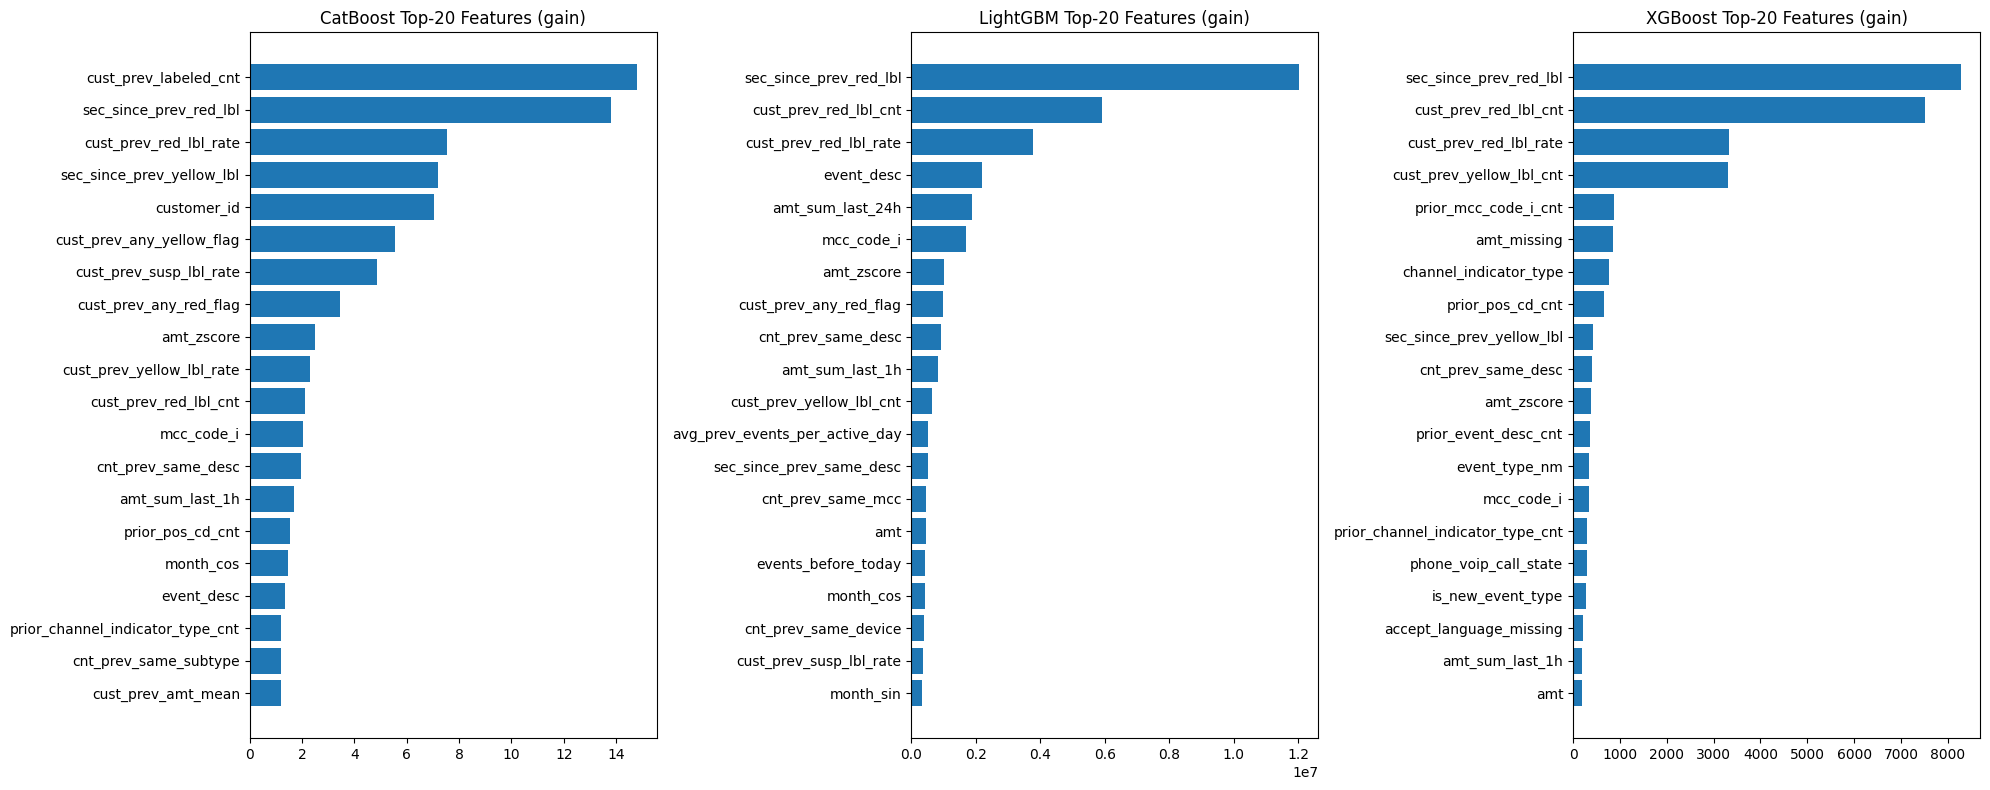

In [23]:
# ==================== FEATURE IMPORTANCE ====================

import matplotlib.pyplot as plt

# Reload models for importance analysis
_cb_imp_path = CACHE_DIR / ("cb_main_full.cbm" if RETRAIN_ON_FULL_CB else "cb_main.cbm")
_model_cb_imp = CatBoostClassifier().load_model(str(_cb_imp_path))
cb_imp = _model_cb_imp.get_feature_importance()
cb_feat_names = _model_cb_imp.feature_names_ if hasattr(_model_cb_imp, "feature_names_") else FULL_FEATURE_COLS
cb_feat_imp = pd.DataFrame({"feature": cb_feat_names, "importance": cb_imp}).sort_values("importance", ascending=False)
del _model_cb_imp

_lgb_imp_path = CACHE_DIR / ("lgb_main_full.txt" if RETRAIN_ON_FULL_LGB else "lgb_main.txt")
_model_lgb_imp = lgb.Booster(model_file=str(_lgb_imp_path))
lgb_imp_raw = _model_lgb_imp.feature_importance(importance_type="gain")
lgb_feat_imp = pd.DataFrame({
    "feature": FULL_FEATURE_COLS[:len(lgb_imp_raw)],
    "importance": lgb_imp_raw,
}).sort_values("importance", ascending=False)
del _model_lgb_imp

_xgb_imp_path = CACHE_DIR / ("xgb_main_full.json" if RETRAIN_ON_FULL_XGB else "xgb_main.json")
_model_xgb_imp = xgb.Booster()
_model_xgb_imp.load_model(str(_xgb_imp_path))
xgb_imp_dict = _model_xgb_imp.get_score(importance_type="gain")
xgb_feat_imp = pd.DataFrame([
    {"feature": f, "importance": xgb_imp_dict.get(f, 0.0)} for f in FULL_FEATURE_COLS
]).sort_values("importance", ascending=False)
del _model_xgb_imp; gc.collect()

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
for ax, df_imp, title in zip(
    axes,
    [cb_feat_imp, lgb_feat_imp, xgb_feat_imp],
    ["CatBoost", "LightGBM", "XGBoost"],
):
    top = df_imp.head(20)
    ax.barh(top["feature"].values[::-1], top["importance"].values[::-1])
    ax.set_title(f"{title} Top-20 Features (gain)")
plt.tight_layout()
plt.show()

In [24]:
# ==================== RESULTS TABLE ====================

results_rows = [
    ("CatBoost", ap_cb, str(best_iter_cb)),
    ("LightGBM", ap_lgb, str(best_iter_lgb)),
    ("XGBoost", ap_xgb, str(best_iter_xgb)),
    ("ExtraTrees", ap_et, str(ET_PARAMS["n_estimators"])),
    ("Simple MLP", ap_mlp, str(best_epoch_mlp)),
]
for combo_name, res in blend_results.items():
    results_rows.append((f"Blend: {combo_name}", res["val_ap"], "-"))

results = pd.DataFrame(results_rows, columns=["Model", "Val PR-AUC", "Best Iter/Epoch"])
results = results.sort_values("Val PR-AUC", ascending=False)
results["Val PR-AUC"] = results["Val PR-AUC"].apply(lambda x: f"{x:.6f}" if isinstance(x, float) else x)
print("\n" + results.to_string(index=False))

print(f"\nBest blend: {best_combo_name} (PR-AUC = {best_meta_ap:.6f})")
print(f"Blend weights: { {blend_keys[i]: round(float(best_meta_w[i]), 4) for i in range(len(blend_keys))} }")
print(f"\nSubmission files saved to: {SUBMISSION_DIR.resolve()}")



            Model Val PR-AUC Best Iter/Epoch
 Blend: 3boost_et   0.480074               -
   Blend: lgb_xgb   0.480028               -
    Blend: 3boost   0.480022               -
      Blend: all5   0.479859               -
    Blend: cb_lgb   0.479147               -
         LightGBM   0.479093             298
    Blend: cb_xgb   0.469232               -
          XGBoost   0.466122             575
Blend: 3boost_mlp   0.465643               -
         CatBoost   0.433256             155
    Blend: et_mlp   0.406248               -
       Simple MLP   0.399879              18
       ExtraTrees   0.335971             200

Best blend: 3boost_et (PR-AUC = 0.480074)
Blend weights: {'catboost': 0.0185, 'lightgbm': 0.763, 'xgboost': 0.2185, 'extratrees': 0.0}

Submission files saved to: D:\prog\ml\data_fusion\local_df\submission_meta


In [27]:
# ==================== MEGA-ENSEMBLE: meta3b1n + sol_154 ====================
# Logit z-score blending (метод из sol_154/AGI/blend_submissions.py)
# Работаем через CSV-файлы, merge по event_id — надёжно и без проблем с разным набором строк

SOL154_BLEND_PATH = Path("sol_154/AGI/sub_totalblend.csv")


def _logit(p: np.ndarray, eps: float = 1e-7) -> np.ndarray:
    p = np.clip(p, eps, 1.0 - eps)
    return np.log(p / (1.0 - p))


def _zscore(x: np.ndarray) -> np.ndarray:
    return (x - x.mean()) / (x.std() + 1e-12)


def _sigmoid(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-x))


def mega_logit_zscore_blend(
    preds: Dict[str, np.ndarray],
    weights: Dict[str, float],
    eps: float = 1e-7,
) -> np.ndarray:
    """Multi-way logit z-score blend: logit -> zscore -> weighted avg -> sigmoid."""
    total_w = sum(weights[k] for k in preds)
    z_blend = np.zeros(len(next(iter(preds.values()))), dtype=np.float64)
    for name, pred in preds.items():
        w = weights[name] / total_w
        z_i = _zscore(_logit(pred, eps))
        nan_cnt = int(np.isnan(z_i).sum())
        if nan_cnt > 0:
            print(f"  WARNING: {name} has {nan_cnt} NaN after logit+zscore, filling with 0")
            z_i = np.nan_to_num(z_i, nan=0.0)
        z_blend += w * z_i
    return _sigmoid(z_blend)


# -- Загружаем все входы как CSV и merge по event_id через sample_submit --
sol154_df = pd.read_csv(SOL154_BLEND_PATH)
print(f"Loaded sol_154 blend: {SOL154_BLEND_PATH} ({len(sol154_df):,} rows)")

# Собираем все наши submissions (уже сохранены выше) + sol154
mega_sub_sources = {
    "catboost":   SUBMISSION_DIR / "submission_cb.csv",
    "lightgbm":   SUBMISSION_DIR / "submission_lgb.csv",
    "xgboost":    SUBMISSION_DIR / "submission_xgb.csv",
    "extratrees": SUBMISSION_DIR / "submission_et.csv",
    "mlp":        SUBMISSION_DIR / "submission_mlp.csv",
    f"my_best_blend ({best_combo_name})": SUBMISSION_DIR / f"submission_blend_{best_combo_name}.csv",
}

# Базовый фрейм — event_id из sample_submit (гарантированный формат)
mega_df = sample_submit[["event_id"]].copy()

# Присоединяем наши 6 submissions
for label, path in mega_sub_sources.items():
    sub = pd.read_csv(path)
    mega_df = mega_df.merge(sub.rename(columns={"predict": label}), on="event_id", how="left")
    n_miss = int(mega_df[label].isna().sum())
    print(f"  {label:40s}: loaded {len(sub):,} rows, missing after merge: {n_miss}")

# Присоединяем sol_154
mega_df = mega_df.merge(
    sol154_df.rename(columns={"predict": "sol154"}), on="event_id", how="left"
)
n_miss_sol = int(mega_df["sol154"].isna().sum())
print(f"  {'sol154':40s}: loaded {len(sol154_df):,} rows, missing after merge: {n_miss_sol}")

# Собираем массивы предсказаний
mega_names = list(mega_sub_sources.keys()) + ["sol154"]
mega_inputs = {}
for name in mega_names:
    vals = mega_df[name].values.astype(np.float64)
    n_nan = int(np.isnan(vals).sum())
    if n_nan > 0:
        med = np.nanmedian(vals)
        print(f"  WARNING: {name} has {n_nan} NaN, filling with median={med:.6f}")
        vals = np.where(np.isnan(vals), med, vals)
    mega_inputs[name] = vals

# -- Веса: пропорциональны val PR-AUC для наших моделей --
val_scores = {
    "catboost": ap_cb,
    "lightgbm": ap_lgb,
    "xgboost": ap_xgb,
    "extratrees": ap_et,
    "mlp": ap_mlp,
}
best_blend_label = f"my_best_blend ({best_combo_name})"

# Нормализация: сумма весов 5 моделей = 1.0, бленд = 1.0, sol154 = 1.0 → итого ~3 группы
sum_val = sum(val_scores.values())
mega_weights = {}
for name, score in val_scores.items():
    mega_weights[name] = score / sum_val  # пропорционально val AP, сумма = 1.0
mega_weights[best_blend_label] = 1.0      # столько же, сколько все 5 моделей вместе
mega_weights["sol154"] = 1.0              # столько же

print("\nMega-ensemble weights (before normalization):")
total_w = sum(mega_weights.values())
for name, w in mega_weights.items():
    print(f"  {name:40s}: {w:.4f}  ({w / total_w * 100:.1f}%)")

# -- Корреляция Спирмена между входами (диагностика) --
from scipy.stats import spearmanr
print("\nSpearman rank correlations (pairwise):")
for i in range(len(mega_names)):
    for j in range(i + 1, len(mega_names)):
        r, _ = spearmanr(mega_inputs[mega_names[i]], mega_inputs[mega_names[j]])
        print(f"  {mega_names[i]:30s} vs {mega_names[j]:30s}: {r:.4f}")

# -- Стратегия A: sol154 + только diverse модели (ET, MLP, CB — низкая корреляция с sol154) --
# Убираем my_best_blend (corr=0.997 с LGB — дубликат) и LGB/XGB (corr>0.83 с sol154)
diverse_inputs = {k: mega_inputs[k] for k in ["catboost", "extratrees", "mlp", "sol154"]}

# -- Стратегия B: sol154 + наш лучший бленд (простой 2-way blend) --
two_way_inputs = {best_blend_label: mega_inputs[best_blend_label], "sol154": mega_inputs["sol154"]}

# -- Стратегия C: sol154 + все 5 моделей (без дублирующего бленда) --
no_blend_inputs = {k: mega_inputs[k] for k in ["catboost", "lightgbm", "xgboost", "extratrees", "mlp", "sol154"]}

STRATEGIES = {
    "diverse": (diverse_inputs, {"catboost": 1.0, "extratrees": 1.0, "mlp": 1.0, "sol154": 1.0}),
    "2way":    (two_way_inputs, {best_blend_label: 1.0, "sol154": 1.0}),
    "5models": (no_blend_inputs, {"catboost": 1.0, "lightgbm": 1.0, "xgboost": 1.0, "extratrees": 1.0, "mlp": 1.0, "sol154": 1.0}),
}

SOL154_GRID = [0.55, 0.65, 0.75, 0.85, 0.90, 0.95]

print(f"\nGenerating mega-ensemble grid ({len(STRATEGIES)} strategies x {len(SOL154_GRID)} weights):")
for strat_name, (strat_inputs, base_weights) in STRATEGIES.items():
    my_keys = [k for k in base_weights if k != "sol154"]
    my_base_total = sum(base_weights[k] for k in my_keys)
    for sol_share in SOL154_GRID:
        my_share = 1.0 - sol_share
        grid_w = {k: my_share * (base_weights[k] / my_base_total) for k in my_keys}
        grid_w["sol154"] = sol_share

        pred = mega_logit_zscore_blend(strat_inputs, grid_w, eps=1e-7)
        tag = f"mega_{strat_name}_sol{int(sol_share * 100)}"
        out = mega_df[["event_id"]].copy()
        out["predict"] = pred
        out_path = SUBMISSION_DIR / f"submission_{tag}.csv"
        out.to_csv(out_path, index=False)
        print(f"  {tag:35s} -> {out_path.name}")


Loaded sol_154 blend: sol_154\AGI\sub_totalblend.csv (633,683 rows)
  catboost                                : loaded 633,683 rows, missing after merge: 0
  lightgbm                                : loaded 633,683 rows, missing after merge: 0
  xgboost                                 : loaded 633,683 rows, missing after merge: 0
  extratrees                              : loaded 633,683 rows, missing after merge: 0
  mlp                                     : loaded 633,683 rows, missing after merge: 0
  my_best_blend (3boost_et)               : loaded 633,683 rows, missing after merge: 0
  sol154                                  : loaded 633,683 rows, missing after merge: 0

Mega-ensemble weights (before normalization):
  catboost                                : 0.2049  (6.8%)
  lightgbm                                : 0.2266  (7.6%)
  xgboost                                 : 0.2205  (7.3%)
  extratrees                              : 0.1589  (5.3%)
  mlp                            